# Ewe n-gram language model — main flow

This notebook is the **main path** of the project. Run it **top to bottom** (in VS Code: "Run All").
Every stage from `plan.md` gets added below as we finish it. Side experiments (like the 15 split ratios) live in their own folders; this notebook uses the best choice from each.

**How to read it:** every step shows
1. **BEFORE → AFTER** — the numbers, and how much changed
2. **Examples** — real sentences showing what changed
3. and each stage ends with a **summary** of what happened to the data.

Why each decision was made: see the decision log in `current-notes.md` (and the comments in each cell).

## Settings
`SPLIT` picks which train/dev/test split the main path uses. We don't know the best one yet — change this one line once the split experiments tell us.

In [1]:
# Settings and helpers used by every stage below.
# show_change / show_changed / examples print the before-after view each step reports.
import random
from collections import Counter

import pyarrow.parquet as pq
from IPython.display import Markdown, display

from stage0_audit import OUT, REPORT, SRC, clean, fix_eth, is_ewe, near_dup_key, nfc, selfcheck, vocab, write_splits

SPLIT = "90-5-5"
random.seed(0)  # so the random samples below are the same every run
selfcheck()     # quick tests of the helper functions; an error here means a helper is broken


def show_change(what, before, after):
    """Print one BEFORE → AFTER line."""
    diff = after - before
    pct = f"{abs(diff) / before:.1%}" if before else "n/a"
    word = "removed" if diff < 0 else "added" if diff > 0 else "no change"
    print(f"{what}:  BEFORE {before:,}  →  AFTER {after:,}   ({word}: {abs(diff):,} = {pct})")


def show_changed(what, n, total):
    """Print how many items a step modified (without removing any)."""
    print(f"{what} changed:  {n:,} of {total:,}  ({n / total:.1%})")


def examples(pairs, k):
    """Up to k different (before, after) pairs, preferring short sentences so they print whole."""
    out = []
    for a, b in pairs:
        if len(a) <= 90 and (a, b) not in out:
            out.append((a, b))
        if len(out) == k:
            break
    return out

# Stage 0 — Data audit
Goal: turn the raw download into clean Ewe sentences, split into train / dev / test.

## 0.1 Load the data
The file has 3 columns: `similarity` (how confident the web-mining program was that the pair are translations), `English`, and `Ewe`.

In [2]:
# Load the raw parquet file into three plain Python lists (one entry per row) and show the first rows.
t = pq.read_table(SRC)
sim, en, ee = t["similarity"].to_pylist(), t["English"].to_pylist(), t["Ewe"].to_pylist()
v_raw = vocab(ee)
print(f"{len(ee):,} rows   |   {v_raw:,} different Ewe words   |   similarity from {min(sim):.3f} to {max(sim):.3f}\n")
print("First 5 rows  (similarity | Ewe || English):")
for i in range(5):
    print(f"  {sim[i]:.3f} | {ee[i]} || {en[i]}")
table = [("rows in", len(ee), f"Ewe vocab {v_raw:,} / English vocab {vocab(en):,} (vocab = number of different words)")]

4,408,322 rows   |   600,335 different Ewe words   |   similarity from 1.050 to 1.250

First 5 rows  (similarity | Ewe || English):
  1.250 | Eye woayɔ wò be Afetɔ ƒe du, || After that you will be called the City of Righteousness,
  1.250 | Nya la do tso nye nu me le dzɔdzɔenyenye me, || The word has gone out of my mouth in righteousness,
  1.250 | Wò fetu asɔ gbɔ ŋutɔ." || Your reward will be very great."
  1.249 | Ena wova sesẽ wu woƒe ketɔwo, || He made them stronger than their enemies.
  1.249 | ʋɔnudrɔŋkekea dzi, elabena míaƒe agbenɔnɔ le xexe sia me sɔ kple etɔ. || boldness on the day of judgment, because as he is, so are we in this world.


## 0.2 Normalise (NFC)
NFC makes letters that *look* the same also be *stored* the same (e.g. `é` as one character, not `e` + accent).

In [3]:
# Apply Unicode NFC normalisation to every sentence and count how many changed (spoiler: none).
ee_nfc, en_nfc = [nfc(s) for s in ee], [nfc(s) for s in en]
changed = sum(a != b for a, b in zip(ee, ee_nfc)), sum(a != b for a, b in zip(en, en_nfc))
v_nfc = vocab(ee_nfc)
show_changed("Ewe sentences", changed[0], len(ee))
show_changed("English sentences", changed[1], len(en))
show_change("Different Ewe words", v_raw, v_nfc)
print("\nExamples of changed sentences:", "none — the data was already NFC" if not changed[0] else "")
table.append(("after NFC", len(ee), f"rows changed Ewe {changed[0]:,} / English {changed[1]:,}; Ewe vocab {v_nfc:,}"))

Ewe sentences changed:  0 of 4,408,322  (0.0%)
English sentences changed:  0 of 4,408,322  (0.0%)
Different Ewe words:  BEFORE 600,335  →  AFTER 600,335   (no change: 0 = 0.0%)

Examples of changed sentences: none — the data was already NFC


## 0.3 Clean spaces and fix `Ð` → `Ɖ`
Extra spaces make identical sentences look different. `Ð` (an Icelandic letter) was used as a look-alike for the Ewe letter `Ɖ`.
In the examples, the text is shown between `[` `]` so you can see the spaces at the edges.

In [4]:
# Apply Unicode NFC normalisation to every sentence and count how many changed (spoiler: none).
ee_clean, en_clean = [fix_eth(clean(s)) for s in ee_nfc], [clean(s) for s in en_nfc]
changed = sum(a != b for a, b in zip(ee_nfc, ee_clean))
v_clean = vocab(ee_clean)
show_changed("Ewe sentences", changed, len(ee))
show_change("Different Ewe words", v_nfc, v_clean)

pairs = list(zip(ee_nfc, ee_clean))
space_ex = examples(((a, b) for a, b in pairs if a != b and "Ð" not in a), 3)
eth_ex = examples(((a, b) for a, b in pairs[::7] if "Ð" in a and a != b), 5)  # [::7] spreads examples out
print("\nExamples — spaces cleaned:")
for a, b in space_ex:
    print(f"  before: [{a}]\n  after:  [{b}]\n")
print("Examples — Ð fixed to Ɖ:")
for a, b in eth_ex:
    print(f"  before: [{a}]\n  after:  [{b}]\n")
del pairs
table.append(("after whitespace + Ð→Ɖ", len(ee), f"Ewe rows changed {changed:,}; Ewe vocab {v_clean:,}"))
del ee_nfc, en_nfc  # free memory

Ewe sentences changed:  151,727 of 4,408,322  (3.4%)
Different Ewe words:  BEFORE 600,335  →  AFTER 600,266   (removed: 69 = 0.0%)

Examples — spaces cleaned:
  before: [30  Eye mawudɔla la gblɔ nɛ be: "Mègavɔ̃ o, Maria, elabena Mawu ve nuwò.]
  after:  [30 Eye mawudɔla la gblɔ nɛ be: "Mègavɔ̃ o, Maria, elabena Mawu ve nuwò.]

  before: [Mibu ame siwo ƒomevi wòle be mianye ŋu  (11-16)]
  after:  [Mibu ame siwo ƒomevi wòle be mianye ŋu (11-16)]

  before: [46  Ame aɖeke mekpɔ Fofo la kpɔ o,+ negbe ame si tso Mawu gbɔ ko; ame siae kpɔ Fofo+ la.]
  after:  [46 Ame aɖeke mekpɔ Fofo la kpɔ o,+ negbe ame si tso Mawu gbɔ ko; ame siae kpɔ Fofo+ la.]

Examples — Ð fixed to Ɖ:
  before: [Mawu Ðoa Eteƒe Na Ame Siwo Dinɛ Vevie _ Nusɔsrɔ̃]
  after:  [Mawu Ɖoa Eteƒe Na Ame Siwo Dinɛ Vevie _ Nusɔsrɔ̃]

  before: [Ðe nyemenyo na wò wu viŋutsu ewo oa?"]
  after:  [Ɖe nyemenyo na wò wu viŋutsu ewo oa?"]

  before: [Ðe Miesusui Be Miawo Koe Akpɔ Ðeɖea?]
  after:  [Ɖe Miesusui Be Miawo Koe Akpɔ Ɖeɖea?]

 

## 0.4 Remove duplicate Ewe sentences
Copies make the n-gram model over-count some word combinations. For each Ewe sentence we keep one English partner: the one with the highest similarity score.

In [5]:
# Collapse stray spaces and replace the look-alike letter Ð with the Ewe letter Ɖ; show real before/after examples.
best = {}  # Ewe sentence -> (best similarity, its English partner)
for s, e, x in zip(ee_clean, en_clean, sim):
    if s and (s not in best or x > best[s][0]):
        best[s] = (x, e)
show_change("Ewe sentences", len(ee), len(best))

counts = Counter(ee_clean)  # how many times each Ewe sentence occurs
print("\nMost-copied sentences:")
for s, c in counts.most_common(5):
    print(f"  {c:>5} copies ×  {s[:80]}")

top = counts.most_common(1)[0][0]
partners = [(x, e) for s, e, x in zip(ee_clean, en_clean, sim) if s == top]
print(f"\nExample — '{top}' was paired with {len(partners):,} different English sentences, e.g.:")
for x, e in partners[:5]:
    print(f"  {x:.3f}  {e[:80]}")
print(f"We kept the highest-similarity one:  {best[top][0]:.3f}  {best[top][1][:80]}")
table.append(("deduped on Ewe (non-empty)", len(best), f"{1 - len(best) / len(ee):.1%} of rows were duplicates"))

Ewe sentences:  BEFORE 4,408,322  →  AFTER 995,588   (removed: 3,412,734 = 77.4%)

Most-copied sentences:
   1296 copies ×  Akpe kakakaka miedze agbagba ŋtɔ.
   1252 copies ×  Eɖanye zã loo keli,
   1083 copies ×  Katã ava Fofoa gbɔ,
   1035 copies ×  6 Eya ta tohehe si ame akpa gãtɔ da ɖe nenem me sia dzi la sɔ gbɔ nɛ.
   1016 copies ×  "WOMEKPƆE kpɔ zi ɖeka teti hã be ele nu kom o."



Example — 'Akpe kakakaka miedze agbagba ŋtɔ.' was paired with 1,296 different English sentences, e.g.:
  1.109  I stepped back again and said "I'm yours?
  1.109  Respectable people are respectable.
  1.105  Then Jesus spoke again to them saying, "I am the Light of the world; he who foll
  1.104  the food.. seriously.
  1.103  Why didn't they have any kids?
We kept the highest-similarity one:  1.109  I stepped back again and said "I'm yours?


## 0.5 Keep only Ewe
A sentence counts as Ewe if it has at least one Ewe-only letter (ɖ ƒ ŋ ɔ ɛ ʋ ɣ). Read the samples below — the filter is not perfect.

In [6]:
# Keep only sentences that contain an Ewe-specific letter; show random samples of what was kept and rejected.
kept = {s: e for s, (x, e) in best.items() if is_ewe(s)}
rejected = [s for s in best if not is_ewe(s)]
show_change("Ewe sentences", len(best), len(kept))
print("\nExamples — REJECTED (thrown away):")
for s in random.sample(rejected, 15):
    print("  ✗", s[:90])
print("\nExamples — KEPT:")
for s in random.sample(list(kept), 10):
    print("  ✓", s[:90])
table.append(("Ewe-filtered", len(kept), f"rejection rate {len(rejected) / len(best):.1%} of unique sentences"))

Ewe sentences:  BEFORE 995,588  →  AFTER 295,198   (removed: 700,390 = 70.3%)

Examples — REJECTED (thrown away):
  ✗ Work From Home..A Simple Copy Paste Work
  ✗ la vie boheme b rent
  ✗ Je Tae Woo Japan
  ✗ + 2012 "Litera n-ko gba"
  ✗ Blusa Yoko Tie Dye
  ✗ * Abia Gov, Ikpeazu
  ✗ Soyez^ be ye.
  ✗ Ryeowook l'homme de ma vie <3
  ✗ yea losermeetsworld
  ✗ evilneko:: Nyaa
  ✗ Lester 3 Eye
  ✗ EtiketeTel Avivi
  ✗ 06) Eye to Eye - A Goofy Movie
  ✗ Miia Nuutila _ Facebook
  ✗ TinEye - same-image search

Examples — KEPT:
  ✓ Esi míese nya sia la, mí Paulo ŋumewo kple dua me kristotɔwo katã, míeɖe kuku na Paulo be 
  ✓ 7 Kpɔ nyati si nye "Àte Ŋu Asrɔ̃ Gbe Bubu!" si dze le April 2007, ƒe Nyɔ! me, axa 10-12.
  ✓ Ema asɔ kple gbɔgblɔ na amesi vuvɔ le wɔwɔm eye dɔ le ewum be, 'ƒu dzo, eye ɖu nu nàɖi ƒo'
  ✓ Jɛhova Jeliwuableisia Ti Giingɔ La Kɛ Tia Mia Lee Ta Bawo?
  ✓ Medea bubu eŋu azɔ eye ne mele nu ƒom nɛ la, mezãa nya siwo nye "meɖe kuku" kple "akpe."
  ✓ Egblɔ kpee be: "Akaɖi si tsi l

## 0.6 Split into train / dev / test
- **train** = the textbook (the model learns from it)
- **dev** = practice exams (to pick settings)
- **test** = the final exam (used once, at the end)

All 15 ratios are written to `data/splits/<train>-<dev>-<test>/`. Near-copies of a sentence always land in the same split.

In [7]:
# Write all 15 train/dev/test ratios to data/splits/ and record the audit table in results/stage0_audit.md.
split_table = write_splits(kept)
audit = "| Step | Sentences | Notes |\n|---|---:|---|\n" + "".join(f"| {a} | {b:,} | {c} |\n" for a, b, c in table)
REPORT.parent.mkdir(exist_ok=True)
REPORT.write_text("# Stage 0 data audit\n\n" + audit + "\n## Splits (data/splits/<train>-<dev>-<test>/)\n\n" + split_table, encoding="utf-8")
print(f"Wrote {split_table.count(chr(10)) - 2} split folders to {OUT}/  and the audit table to {REPORT}")
display(Markdown(split_table))

Wrote 15 split folders to data/splits/  and the audit table to results/stage0_audit.md


| Ratio | Train | Dev | Test |
|---|---:|---:|---:|
| 1/49/50 | 3,013 sent / 47,125 tok | 144,544 sent / 2,204,524 tok | 147,641 sent / 2,252,946 tok |
| 5/45/50 | 14,718 sent / 226,872 tok | 132,839 sent / 2,024,777 tok | 147,641 sent / 2,252,946 tok |
| 10/40/50 | 29,324 sent / 450,574 tok | 118,233 sent / 1,801,075 tok | 147,641 sent / 2,252,946 tok |
| 10/45/45 | 29,324 sent / 450,574 tok | 132,938 sent / 2,025,910 tok | 132,936 sent / 2,028,111 tok |
| 20/40/40 | 58,867 sent / 902,153 tok | 118,137 sent / 1,798,872 tok | 118,194 sent / 1,803,570 tok |
| 30/35/35 | 88,442 sent / 1,351,709 tok | 103,445 sent / 1,575,767 tok | 103,311 sent / 1,577,119 tok |
| 40/30/30 | 117,842 sent / 1,800,656 tok | 88,922 sent / 1,353,877 tok | 88,434 sent / 1,350,062 tok |
| 50/25/25 | 147,557 sent / 2,251,649 tok | 73,954 sent / 1,130,031 tok | 73,687 sent / 1,122,915 tok |
| 60/20/20 | 177,004 sent / 2,701,025 tok | 59,366 sent / 906,175 tok | 58,828 sent / 897,395 tok |
| 70/15/15 | 206,764 sent / 3,154,533 tok | 44,353 sent / 677,790 tok | 44,081 sent / 672,272 tok |
| 80/10/10 | 236,370 sent / 3,607,200 tok | 29,512 sent / 450,469 tok | 29,316 sent / 446,926 tok |
| 85/10/5 | 251,117 sent / 3,832,323 tok | 29,470 sent / 451,237 tok | 14,611 sent / 221,035 tok |
| 85/5/10 | 251,117 sent / 3,832,323 tok | 14,765 sent / 225,346 tok | 29,316 sent / 446,926 tok |
| 90/5/5 | 265,882 sent / 4,057,669 tok | 14,705 sent / 225,891 tok | 14,611 sent / 221,035 tok |
| 98/1/1 | 289,310 sent / 4,415,404 tok | 2,932 sent / 44,377 tok | 2,956 sent / 44,814 tok |


## 0.7 Load the split the main path uses — and check nothing leaked
If a test sentence (or a near-copy, like the same verse with a different number) is also in train, the final exam is unfair. Both counts below must be **0**.

In [8]:
# Load the split the main path uses, and check that no test sentence (or near-copy) is in the training data.
def read(name, lang="ewe"):
    return (OUT / SPLIT / f"{name}.{lang}.txt").read_text(encoding="utf-8").splitlines()

train_sentences, dev, test = read("train"), read("dev"), read("test")
total = len(train_sentences) + len(dev) + len(test)
print(f"Using split {SPLIT}:")
for name, part in (("train", train_sentences), ("dev", dev), ("test", test)):
    print(f"  {name:<5} {len(part):>9,} sentences  ({len(part) / total:.1%})")

train_keys = {near_dup_key(s) for s in train_sentences}
print(f"\nTest sentences also in train (exact copy): {len(set(test) & set(train_sentences)):,}")
print(f"Test sentences with a near-copy in train:  {sum(near_dup_key(s) in train_keys for s in test):,}")
print("\nExamples — first 3 training sentences:")
for s in train_sentences[:3]:
    print("  ", s)

Using split 90-5-5:
  train   265,882 sentences  (90.1%)
  dev      14,705 sentences  (5.0%)
  test     14,611 sentences  (4.9%)



Test sentences also in train (exact copy): 0
Test sentences with a near-copy in train:  0

Examples — first 3 training sentences:
   11 Wo viŋutsuwo doa go abe lãha ene,
   Togbɔ be vaseɖe fifia dzɔdzɔmeŋutinunyalawo menya nusi tututue naa tsinyegoe me kansa o hã la, woxɔe se be ƒometɔ ŋu nɔnɔ kple lãmetsiŋusẽ wɔa akpa aɖe.
   Gake ɖe afɔku aɖe le ewɔwɔ wòagbɔ eme mea?


## Stage 0 summary — what happened to the data

In [9]:
# Stage 0 summary: a text bar chart of how much data survived each step.
print("How many sentences were left after each step:\n")
for step, n, _ in table:
    print(f"  {step:<28} {n:>10,}  {'█' * max(1, round(50 * n / table[0][1]))}")
print(f"\nUsable Ewe sentences: {len(kept):,} of {len(ee):,} rows = {len(kept) / len(ee):.1%} of the download")
display(Markdown(audit))

How many sentences were left after each step:

  rows in                       4,408,322  ██████████████████████████████████████████████████
  after NFC                     4,408,322  ██████████████████████████████████████████████████
  after whitespace + Ð→Ɖ        4,408,322  ██████████████████████████████████████████████████
  deduped on Ewe (non-empty)      995,588  ███████████
  Ewe-filtered                    295,198  ███

Usable Ewe sentences: 295,198 of 4,408,322 rows = 6.7% of the download


| Step | Sentences | Notes |
|---|---:|---|
| rows in | 4,408,322 | Ewe vocab 600,335 / English vocab 989,225 (vocab = number of different words) |
| after NFC | 4,408,322 | rows changed Ewe 0 / English 0; Ewe vocab 600,335 |
| after whitespace + Ð→Ɖ | 4,408,322 | Ewe rows changed 151,727; Ewe vocab 600,266 |
| deduped on Ewe (non-empty) | 995,588 | 77.4% of rows were duplicates |
| Ewe-filtered | 295,198 | rejection rate 70.3% of unique sentences |


# Stage 0 follow-ups: testing every data decision

Stage 0 made choices (which split ratio, which cleaning steps, which filter). Each one is tested here by changing it and measuring what happens to the same model (modified Kneser-Ney, order 5). Scripts: `stage0_splits.py`, `stage0_ablation.py`, `stage0_filter_test.py`.

In [1]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

show_md("split_ratios.md")

# Split ratios

Same model (modified Kneser-Ney, order 5, whitespace) trained on every ratio. 'Common test' = the 98/1/1 test set (2,956 sentences), which no ratio ever trains on, so that column is the fair comparison.

| split | train sentences | own dev | own test | common: all tokens | common: known words | common bits/char | OOV on common |
|---|---:|---:|---:|---:|---:|---:|---:|
| 1-49-50 | 3,013 | 178.2 | 177.9 | 178.7 | 306.6 | 1.631 | 15.33% |
| 5-45-50 | 14,718 | 203.5 | 202.6 | 206.4 | 261.2 | 1.676 | 8.34% |
| 10-45-45 | 29,324 | 193.9 | 193.6 | 194.7 | 227.6 | 1.658 | 6.41% |
| 10-40-50 | 29,324 | 194.0 | 193.5 | 194.7 | 227.6 | 1.658 | 6.41% |
| 20-40-40 | 58,867 | 171.3 | 170.8 | 171.3 | 188.3 | 1.618 | 4.75% |
| 30-35-35 | 88,442 | 154.8 | 153.5 | 153.6 | 164.2 | 1.583 | 3.97% |
| 40-30-30 | 117,842 | 141.1 | 139.9 | 140.3 | 147.6 | 1.555 | 3.46% |
| 50-25-25 | 147,557 | 130.0 | 129.1 | 129.1 | 134.4 | 1.529 | 3.14% |
| 60-20-20 | 177,004 | 121.1 | 119.5 | 118.7 | 122.6 | 1.502 | 2.93% |
| 70-15-15 | 206,764 | 112.5 | 112.3 | 110.6 | 113.6 | 1.480 | 2.72% |
| 80-10-10 | 236,370 | 104.3 | 106.2 | 104.5 | 106.8 | 1.462 | 2.56% |
| 85-10-5 | 251,117 | 102.9 | 102.5 | 101.1 | 103.1 | 1.452 | 2.48% |
| 85-5-10 | 251,117 | 101.7 | 103.3 | 101.1 | 103.1 | 1.452 | 2.48% |
| 90-5-5 | 265,882 | 100.8 | 99.8 | 98.8 | 100.5 | 1.444 | 2.41% |
| 98-1-1 | 289,310 | 99.2 | 95.2 | 95.2 | 96.6 | 1.433 | 2.30% |

## How much a dev estimate wobbles with dev size (90/5/5 model, 8 random draws per size)

| dev sentences | lowest | highest | spread |
|---:|---:|---:|---:|
| 100 | 78.8 | 119.5 | 40.7 |
| 300 | 95.0 | 113.6 | 18.6 |
| 1,000 | 90.9 | 102.9 | 11.9 |
| 3,000 | 97.3 | 106.9 | 9.7 |
| 10,000 | 99.1 | 101.8 | 2.6 |


**Reading the split table.** Each ratio has its own dev/test, so those columns are different exams and cannot be compared across rows. The *common test* (the 98/1/1 test set, hash bucket 0, which no ratio trains on) is the fair exam.

**The trap.** On all tokens, the 1% split beats the 5% split on the common exam. With tiny training data 15% of exam words are unknown, and the model's reserved share for unknown words is so large (13.9%) that each unknown word costs only 2.8 bits, cheaper than a known word. Score known words only and the truth appears: the 1% model is the worst of all. Unknown-word handling can flatter perplexity; this is that warning in our own table.

**Dev size.** Eight random draws of the dev set at each size: 100 sentences wobble by 40 points, 10,000 by 3. That is why 5% (about 15,000) was right.

In [2]:
# Stage 0 follow-ups: testing every data decision: read the saved results and print them.
r = load("split_ratios.json")
print(f"{'split':>8} {'train':>8} {'common test (all tokens)':>25} {'common test (known words)':>26} {'bits/char':>10} {'OOV':>7}")
for f, row in r["ratios"].items():
    print(f"{f:>8} {row['train']:>8,} {row['common_pp']:>25.1f} {row['common_pp_known']:>26.1f} {row['common_bpc']:>10.3f} {row['common_oov']:>7.2%}")

   split    train  common test (all tokens)  common test (known words)  bits/char     OOV
 1-49-50    3,013                     178.7                      306.6      1.631  15.33%
 5-45-50   14,718                     206.4                      261.2      1.676   8.34%
10-45-45   29,324                     194.7                      227.6      1.658   6.41%
10-40-50   29,324                     194.7                      227.6      1.658   6.41%
20-40-40   58,867                     171.3                      188.3      1.618   4.75%
30-35-35   88,442                     153.6                      164.2      1.583   3.97%
40-30-30  117,842                     140.3                      147.6      1.555   3.46%
50-25-25  147,557                     129.1                      134.4      1.529   3.14%
60-20-20  177,004                     118.7                      122.6      1.502   2.93%
70-15-15  206,764                     110.6                      113.6      1.480   2.72%
80-10-10  

## Leave one preparation step out
Same model, same dev exam where the step does not change which sentences exist. The random-split row is the one to stare at: the *only* change that makes the score better, and it does so by leaking near-copies of dev sentences into training.

In [3]:
# Leave one preparation step out: display the table the experiment script wrote to results/.
show_md("ablation.md")
r = load("ablation.json")
base = r["baseline (all steps)"]["dev_pp"]
for k, v in r.items():
    print(f"{k:<28} dev perplexity {v['dev_pp']:>7.1f}  ({v['dev_pp'] / base - 1:+6.1%} vs baseline)")

# Ablation: leave one preparation step out

Modified Kneser-Ney, order 5, whitespace tokens. Dev perplexity (lower is better).

| variant | train sentences | vocabulary | dev perplexity | known words only | bits/char | note |
|---|---:|---:|---:|---:|---:|---|
| baseline (all steps) | 265,882 | 169,245 | 100.8 | 102.7 | 1.447 | the Stage 0 pipeline |
| without NFC | 265,882 | 169,245 | 100.8 | 102.7 | 1.447 | NFC changed 0 rows, so this is identical |
| without whitespace cleanup | 266,817 | 169,245 | 100.8 | 102.6 | 1.447 | extra/leading spaces kept; ' s' and 's' no longer merge in dedupe or the split key (different dev set) |
| without the Ð→Ɖ fix | 249,693 | 164,209 | 103.2 | 105.3 | 1.456 | Ð-spelled words stay separate vocabulary entries (different dev set) |
| without dedupe | 2,303,964 | 169,245 | 142.6 | 136.0 | 1.556 | training keeps all copies (a hub sentence 1,000+ times); dev is deduped so the exam is the same |
| random split (leakage) | 280,493 | 174,358 | 93.1 | 94.5 | 1.424 | 352 of 14,705 dev sentences (2.4%) have a near-copy in train (different dev set) |

Also measured elsewhere: the Ewe filter (results/filter_test.md: no filter = 25% worse) and smoothing (results/dev_and_smoothing_checks.json: plain counting = infinite perplexity on 81% of dev sentences).


baseline (all steps)         dev perplexity   100.8  ( +0.0% vs baseline)
without NFC                  dev perplexity   100.8  ( +0.0% vs baseline)
without whitespace cleanup   dev perplexity   100.8  ( -0.0% vs baseline)
without the Ð→Ɖ fix          dev perplexity   103.2  ( +2.4% vs baseline)
without dedupe               dev perplexity   142.6  (+41.4% vs baseline)
random split (leakage)       dev perplexity    93.1  ( -7.7% vs baseline)


## Grading the filter with a language identifier
GlotLID (Kargaran et al., 2023) recognises about 2,100 languages including Ewe, Ga, Fon, Twi and Adangme. It is used here only to *grade* our letter filter, as a stand-in for the native-speaker audit the plan wanted; it is not our filter. The standard fastText identifier does not know Ewe at all.

In [4]:
# Grading the filter with a language identifier: display the table the experiment script wrote to results/.
show_md("filter_test.md")

# Filter tests

## A. Religious-text skew

35.0% of training sentences contain a Bible/church keyword or start with a verse number (12.8% start with a verse number). This is a lower bound.

## B. GlotLID (a real language identifier) vs our letter filter

- Of the 295,198 sentences our filter KEPT, GlotLID calls 92.4% Ewe.
- Of the 700,390 it REJECTED, GlotLID calls 10.7% Ewe.
- Of our dev set, GlotLID calls 92.1% Ewe.

Top languages among kept: ewe_Latn 272,893, gaa_Latn 2,769, ajg_Latn 2,480, nzi_Latn 1,370, akp_Latn 1,257, ada_Latn 1,159, dyi_Latn 800, men_Latn 799

Top languages among rejected: ewe_Latn 74,923, pcm_Latn 53,357, bew_Latn 52,702, eng_Latn 13,909, kiu_Latn 13,555, dag_Latn 12,929, nrm_Latn 12,525, nap_Latn 12,028

Kept by us, not Ewe per GlotLID (sample):

- JW January 2019 Na'am Mɔɔlegɔ Yetɔɣum — gur_Latn (0.96)
- George Young vale nyevile zo fane dɔɔnwo dule adenle bɔle edwɛkpa nolo — nzi_Latn (1.0)
- Maybe ʌ lɔkɔ lɔm — men_Latn (0.51)
- "Ɛseta Dule Ɔ Nwo Maanle Gyihova Nee Ye Menli Ne": (Mit. — nzi_Latn (1.0)
- ge>ge: lulɔ — tod_Latn (0.77)
- Nu Enɛ: Nwīekpo kpa ama aara "le yereue loo lenu" nyɔnɛbee a lu yereue a le bu Baibol. — ogo_Latn (1.0)
- $1 vaseɖe $2 — und_Lina (0.37)
- Kɛ́ amrɔ nɛɛ ojeee gbɛgbalɔ lɛ, mɛɛ tsakemɔi obaanyɛ ofee koni obatsɔ gbɛgbalɔ? — gaa_Latn (1.0)
- Shi ni owo lɛ, ye nɔ." - Jajelɔ 5:4 — gaa_Latn (1.0)
- Gbɔmɛi kome - — gaa_Latn (0.99)
- Namɔ Ji Nuu ni Woloŋmaa Tɔ Ŋmɔ Ehɛ Lɛ? - Ezekiel 9:2 _ Nikasemɔ — gaa_Latn (1.0)
- 59 Yː Ni yɔɔ dzaanɔ̄ ... — gaa_Latn (0.93)

Rejected by us, Ewe per GlotLID (sample):

- Late Lammas 4 kpl (0.39)
- Zigbee Enabled Tablets _ eBay (0.49)
- 9 eye dzi beads power (1.0)
- Wo, wo, wo, un moment, Mme la Présidente. (0.5)
- Archive - You make me feel? (0.25)
- Egbe Vado - Alone Soul uploaded by Egbe Vado - Listen (0.76)
- Tso - Nafusi (1.0)
- Vanessa Paradis Joe Le Taxi Meme (0.64)
- Send private message to agbadza (0.57)
- 'Nu wowwie Wunnie, id nu be wong time.' (0.32)
- My Two Cents: Home Again, Home Again (0.37)
- Eye Am That Eye Am: The Hipnotic Eye (0.85)

## C. Filter on vs off (modified Kneser-Ney, order 3, scored on the filtered dev set)

| training set | sentences | vocabulary | dev perplexity | known words only | bits/char |
|---|---:|---:|---:|---:|---:|
| letter filter (ours) | 265,882 | 169,245 | 123.8 | 126.6 | 1.512 |
| no filter | 896,230 | 558,960 | 155.2 | 161.8 | 1.583 |
| GlotLID filter | 313,315 | 186,700 | 124.4 | 129.1 | 1.513 |


## Three more Ewe sources, and spoken Ewe
Our corpus is one mined web source, 35% religious text. Three more sources exist: a Bible/JW sentence-pair CSV, a dictionary export (Glosbe and peterlin.pl examples), and the University of Ghana **Waxal** project's transcribed *spoken* image descriptions, the only conversational Ewe we have. `stage0_sources.py` cleans them with the Stage 0 rules plus the extras these files need (broken binary rows, HTML, URLs, zero-width characters, the Greek ε and lower-case ð look-alikes), removes sentences already in our corpus, and splits them with the same hash rule.

Two questions: how does the web-only model do on each source, especially speech? And does adding the sources to training help?

In [5]:
# Three more Ewe sources, and spoken Ewe: display the table the experiment script wrote to results/.
show_md("multisource.md")
r = load("multisource.json")["scores"]
a, b = r["web only (main path)"]["dev"], r["web + three sources"]["dev"]
print(f"Spoken Ewe: bits/char {a['speech']['bpc']:.3f} -> {b['speech']['bpc']:.3f}; unknown words {a['speech']['oov']:.1%} -> {b['speech']['oov']:.1%}")
print(f"Web dev:    bits/char {a['web']['bpc']:.3f} -> {b['web']['bpc']:.3f}")

# Three more Ewe sources

Modified Kneser-Ney, order 5, whitespace tokens. Each source is split with the main split's hash rule; sentences already in the main corpus are removed.

| source | raw lines | new unique sentences | train / dev / test | religious share | passes the letter filter |
|---|---:|---:|---|---:|---:|
| bible_csv | 28,614 | 18,156 | 16,300 / 931 / 925 | 22.0% | 94.9% |
| dictionary | 540 | 367 | 327 / 18 / 22 | 15.5% | 99.2% |
| speech | 19,151 | 19,150 | 17,213 / 982 / 955 | 0.0% | 100.0% |
| web (main corpus) | | | 265,882 / 14,705 / … | 12.8% | 100% (filtered) |

## Bits per character on each source's dev set (lower is better)

| trained on | web | bible_csv | dictionary | speech |
|---|---:|---:|---:|---:|
| web only (main path) (265,882) | 1.447 | 1.304 | 1.519 | 2.119 |
| web + three sources (299,722) | 1.422 | 1.242 | 1.525 | 1.699 |

## Perplexity on known words, and unknown-word rate

| trained on | web | bible_csv | dictionary | speech |
|---|---:|---:|---:|---:|
| web only (main path) | 102.7 (2.4%) | 66.7 (3.1%) | 138.4 (4.0%) | 1315.4 (11.0%) |
| web + three sources | 94.2 (2.3%) | 54.1 (1.6%) | 139.2 (3.0%) | 249.6 (3.1%) |


Spoken Ewe: bits/char 2.119 -> 1.699; unknown words 11.0% -> 3.1%
Web dev:    bits/char 1.447 -> 1.422


**Reading it.** A model of written, largely religious web Ewe is a poor model of speech: 11% of the words people say are unknown to it, and its bits per character jump from 1.45 to 2.12. Adding 34,000 sentences from three sources (13% more data) brings speech down to 1.70 and even improves the web dev set. For Ankora, whose models score *spoken* transcripts, source variety matters more than raw size.

# Stage 1 — What a language model is (worked example)

**Do this on paper first**, then use these cells to check your answers.

A **bigram model** guesses each word using only the word just before it:

  P(word | previous word) = C(previous word, word) / C(previous word)

where **C(...)** means "how many times we counted it" in the training sentences.

We add **`<s>`** (start) before each sentence and **`</s>`** (end) after it, so the first word has something before it and the model learns how sentences end.

**Tokens are split on spaces only**, so punctuation stays attached: `mí` and `mí,` are *different* tokens. Watch for that below.

## 1.1 Count every bigram in 5 training sentences
These 5 sentences are real sentences from our training data.

In [10]:
# The Stage 1 hand example: count every bigram in five real training sentences.
import math
from fractions import Fraction  # exact fractions like 2/5, so the numbers match your paper

toy = ["Aƒetɔ, dzɔ nye.", "Aƒetɔ, va kaba!", "Si va ɖe mí,", "Xɔ mí, ɖe mí", "Eya ɖe mí vavã."]


def with_boundaries(sentence):
    return ["<s>"] + sentence.split() + ["</s>"]


bigram_counts, context_counts = Counter(), Counter()
for s in toy:
    toks = with_boundaries(s)
    for prev, word in zip(toks, toks[1:]):
        bigram_counts[(prev, word)] += 1
        context_counts[prev] += 1

print("BEFORE — the 5 training sentences:")
for s in toy:
    print("  ", s)
print("\nAFTER adding <s> and </s>:")
for s in toy:
    print("  ", " ".join(with_boundaries(s)))
print(f"\nEvery bigram (pair of neighbouring tokens) and its count — {len(bigram_counts)} different pairs:")
for (prev, word), c in bigram_counts.items():
    print(f"  C({prev} {word}) = {c}")
print("\nHow many times each token is the FIRST half of a pair (its count as a 'context'):")
for w, c in context_counts.items():
    print(f"  C({w}) = {c}")

BEFORE — the 5 training sentences:
   Aƒetɔ, dzɔ nye.
   Aƒetɔ, va kaba!
   Si va ɖe mí,
   Xɔ mí, ɖe mí
   Eya ɖe mí vavã.

AFTER adding <s> and </s>:
   <s> Aƒetɔ, dzɔ nye. </s>
   <s> Aƒetɔ, va kaba! </s>
   <s> Si va ɖe mí, </s>
   <s> Xɔ mí, ɖe mí </s>
   <s> Eya ɖe mí vavã. </s>

Every bigram (pair of neighbouring tokens) and its count — 21 different pairs:
  C(<s> Aƒetɔ,) = 2
  C(Aƒetɔ, dzɔ) = 1
  C(dzɔ nye.) = 1
  C(nye. </s>) = 1
  C(Aƒetɔ, va) = 1
  C(va kaba!) = 1
  C(kaba! </s>) = 1
  C(<s> Si) = 1
  C(Si va) = 1
  C(va ɖe) = 1
  C(ɖe mí,) = 1
  C(mí, </s>) = 1
  C(<s> Xɔ) = 1
  C(Xɔ mí,) = 1
  C(mí, ɖe) = 1
  C(ɖe mí) = 2
  C(mí </s>) = 1
  C(<s> Eya) = 1
  C(Eya ɖe) = 1
  C(mí vavã.) = 1
  C(vavã. </s>) = 1

How many times each token is the FIRST half of a pair (its count as a 'context'):
  C(<s>) = 5
  C(Aƒetɔ,) = 2
  C(dzɔ) = 1
  C(nye.) = 1
  C(va) = 2
  C(kaba!) = 1
  C(Si) = 1
  C(ɖe) = 3
  C(mí,) = 2
  C(Xɔ) = 1
  C(mí) = 2
  C(Eya) = 1
  C(vavã.) = 1


## 1.2 Probability and perplexity of a held-out 6th sentence
**"Aƒetɔ, va ɖe mí"** ("Lord, come save us") is not one of the 5 training sentences, but every pair in it appeared somewhere in them.

- Multiply the probability of every pair → the probability of the whole sentence.
- **Perplexity** = P(sentence) ^ (−1/N), where N = number of tokens the model had to predict (the words plus `</s>`; `<s>` is given, not predicted).
- Perplexity ≈ "how many equally likely choices the model felt it had at each step, on average". **Lower is better.**

In [11]:
# Score the held-out sentence pair by pair, printing every count and fraction, and assert it matches the paper answer (1/30).
def score(sentence):
    """Print the calculation pair by pair; return (P(sentence), N, perplexity)."""
    toks = with_boundaries(sentence)
    p = Fraction(1)
    print(f"Sentence: {' '.join(toks)}\n")
    print(f"  {'pair':<22} {'C(pair)':>7} {'C(context)':>10}   P = C(pair) / C(context)")
    for prev, word in zip(toks, toks[1:]):
        c, ctx = bigram_counts[(prev, word)], context_counts[prev]
        step = Fraction(c, ctx) if ctx else Fraction(0)
        p *= step
        print(f"  {prev + ' → ' + word:<22} {c:>7} {ctx:>10}   {c}/{ctx} = {step}")
    n = len(toks) - 1
    pp = math.inf if p == 0 else float(p) ** (-1 / n)
    print(f"\n  P(sentence) = multiply the P column = {p}")
    print(f"  N = {n} predicted tokens (the words + </s>)")
    if pp == math.inf:
        print(f"  Perplexity = 0 ^ (-1/{n}) = 1 / 0 = INFINITY")
    else:
        print(f"  Perplexity = ({p}) ^ (-1/{n}) = {pp:.4f}")
    return p, n, pp


p, n, pp = score("Aƒetɔ, va ɖe mí")
assert p == Fraction(1, 30) and n == 5  # the hand-calculated answer; if this fails, the code (not the paper) is wrong

Sentence: <s> Aƒetɔ, va ɖe mí </s>

  pair                   C(pair) C(context)   P = C(pair) / C(context)
  <s> → Aƒetɔ,                 2          5   2/5 = 2/5
  Aƒetɔ, → va                  1          2   1/2 = 1/2
  va → ɖe                      1          2   1/2 = 1/2
  ɖe → mí                      2          3   2/3 = 2/3
  mí → </s>                    1          2   1/2 = 1/2

  P(sentence) = multiply the P column = 1/30
  N = 5 predicted tokens (the words + </s>)
  Perplexity = (1/30) ^ (-1/5) = 1.9744


## 1.3 Explore: one pair never seen → infinity
**"Aƒetɔ, ɖe mí"** ("Lord, save us") looks just as reasonable. But the pair `Aƒetɔ, → ɖe` never appeared in training.

In [12]:
# The contrast case: one pair never seen in training makes the whole sentence impossible (probability 0, perplexity infinite).
p0, n0, pp0 = score("Aƒetɔ, ɖe mí")
assert p0 == 0 and pp0 == math.inf

Sentence: <s> Aƒetɔ, ɖe mí </s>

  pair                   C(pair) C(context)   P = C(pair) / C(context)
  <s> → Aƒetɔ,                 2          5   2/5 = 2/5
  Aƒetɔ, → ɖe                  0          2   0/2 = 0
  ɖe → mí                      2          3   2/3 = 2/3
  mí → </s>                    1          2   1/2 = 1/2

  P(sentence) = multiply the P column = 0
  N = 4 predicted tokens (the words + </s>)
  Perplexity = 0 ^ (-1/4) = 1 / 0 = INFINITY


## Stage 1 summary — what happened

In [13]:
# Stage 1 summary.
print(f"  'Aƒetɔ, va ɖe mí'  every pair seen in training      →  P = {p}   perplexity = {pp:.2f}")
print(f"  'Aƒetɔ, ɖe mí'     one pair never seen ('Aƒetɔ, → ɖe') →  P = 0      perplexity = ∞")
print()
print("One unseen pair makes the whole sentence impossible (probability 0), so perplexity is infinite.")
print("A real test set has thousands of sentences, so this will happen almost immediately → Stage 3 (smoothing) fixes it.")

  'Aƒetɔ, va ɖe mí'  every pair seen in training      →  P = 1/30   perplexity = 1.97
  'Aƒetɔ, ɖe mí'     one pair never seen ('Aƒetɔ, → ɖe') →  P = 0      perplexity = ∞

One unseen pair makes the whole sentence impossible (probability 0), so perplexity is infinite.
A real test set has thousands of sentences, so this will happen almost immediately → Stage 3 (smoothing) fixes it.


# Stage 2 — Build the counting model

Now we do the same counting as Stage 1, but on the real training data and for **orders 1 to 5**:

| Order | Name | Looks back at |
|---|---|---|
| 1 | unigram | nothing — just how common each word is |
| 2 | bigram | 1 previous token |
| 3 | trigram | 2 previous tokens |
| 4 | 4-gram | 3 previous tokens |
| 5 | 5-gram | 4 previous tokens |

`ORDERS` and `TOKENIZER` below are settings you can change.

In [14]:
# Stage 2 settings; run the counter's self-check against the Stage 1 paper answer; free Stage 0's memory.
import time

from stage2_ngram import BOS, EOS, TOKENIZERS, detokenize, first_unseen, generate, pad, perplexity, prob, train
from stage2_ngram import selfcheck as stage2_selfcheck

ORDERS = [1, 2, 3, 4, 5]
TOKENIZER = "whitespace"

stage2_selfcheck()  # checks the code against the Stage 1 paper answer (P = 1/30, perplexity = 1.974)
print("Stage 2 code agrees with the Stage 1 hand calculation ✓")

for v in ("t", "sim", "en", "ee", "ee_clean", "en_clean", "best", "counts", "rejected", "kept"):
    globals().pop(v, None)  # free the memory Stage 0 used; train_sentences / dev / test stay

Stage 2 code agrees with the Stage 1 hand calculation ✓


## 2.1 Count the n-grams
**Training an n-gram model is just counting.** No GPU, no learning rate, one pass over the data.

Watch the last column: as the order grows, more and more n-grams are seen **only once**. That is *sparsity*, and it is why high orders break.

In [15]:
# Count n-grams at every order and report how many distinct sequences exist and how many were seen only once (sparsity).
models = {}
rows = []
for n in ORDERS:
    t0 = time.time()
    models[n] = m = train(train_sentences, n, TOKENIZER)
    n_grams = sum(len(c) for c in m.counts.values())      # how many different n-grams exist (one Counter per context)
    singles = sum(sum(1 for v in c.values() if v == 1) for c in m.counts.values())  # seen exactly once
    elapsed = time.time() - t0
    rows.append((n, n_grams, singles, singles / n_grams, elapsed))
    print(f"order {n}: {n_grams:>10,} different n-grams | {singles / n_grams:5.1%} seen only once | {elapsed:4.1f}s")

print("\nMost common n-grams at each order:")
for n in ORDERS:
    m = models[n]
    top = Counter({ctx + (w,): c for ctx, ctr in m.counts.items() for w, c in ctr.items()}).most_common(3)
    print(f"  order {n}: " + "   ".join(f"{' '.join(g)!r}×{c:,}" for g, c in top))

order 1:    169,245 different n-grams | 55.4% seen only once |  1.0s


order 2:  1,067,996 different n-grams | 68.1% seen only once |  2.3s


order 3:  2,306,206 different n-grams | 78.7% seen only once |  5.5s


order 4:  3,066,734 different n-grams | 86.0% seen only once |  5.6s


order 5:  3,393,801 different n-grams | 90.0% seen only once |  6.0s

Most common n-grams at each order:
  order 1: '</s>'×265,882   'le'×108,783   'be'×90,284


  order 2: 'o. </s>'×19,697   'me. </s>'×12,687   'ale si'×8,391


  order 3: '<s> <s> Le'×8,062   '<s> <s> Ne'×6,328   '<s> <s> Nu'×5,926


  order 4: '<s> <s> <s> Le'×8,062   '<s> <s> <s> Ne'×6,328   '<s> <s> <s> Nu'×5,926


  order 5: '<s> <s> <s> <s> Le'×8,062   '<s> <s> <s> <s> Ne'×6,328   '<s> <s> <s> <s> Nu'×5,926


## 2.2 Check the code against the Stage 1 paper calculation
Same 5 toy sentences, same held-out sentence — now through the real code.

In [16]:
# The Stage 1 hand example: count every bigram in five real training sentences.
toy = ["Aƒetɔ, dzɔ nye.", "Aƒetɔ, va kaba!", "Si va ɖe mí,", "Xɔ mí, ɖe mí", "Eya ɖe mí vavã."]
toy_model = train(toy, 2, "whitespace")
pp, n_tok, zeros, _ = perplexity(toy_model, ["Aƒetɔ, va ɖe mí"])
print(f"P(mí | ɖe)      = {prob(toy_model, ('ɖe',), 'mí')}   (paper: 2/3 = {2 / 3:.4f})")
print(f"P(</s> | mí)    = {prob(toy_model, ('mí',), EOS)}   (paper: 1/2)")
print(f"perplexity      = {pp:.4f}   (paper: 30^(1/5) = {30 ** 0.2:.4f})   N = {n_tok}, zero-probability tokens = {zeros}")
pp_zero = perplexity(toy_model, ["Aƒetɔ, ɖe mí"])[0]
print(f"'Aƒetɔ, ɖe mí'  → perplexity {pp_zero}, first unseen pair: {first_unseen(toy_model, 'Aƒetɔ, ɖe mí')}")

P(mí | ɖe)      = 0.6666666666666666   (paper: 2/3 = 0.6667)
P(</s> | mí)    = 0.5   (paper: 1/2)
perplexity      = 1.9744   (paper: 30^(1/5) = 1.9744)   N = 5, zero-probability tokens = 0
'Aƒetɔ, ɖe mí'  → perplexity inf, first unseen pair: ('Aƒetɔ,', 'ɖe')


## 2.3 Perplexity on real dev data — and why it is infinite
Now the same measurement on the **dev** set, which the model has never seen.

In [17]:
# Score the dev set with plain counting: how many tokens get probability 0 at each order (all orders end infinite).
pp_rows = []
for n in ORDERS:
    pp, n_tok, zeros, zero_sents = perplexity(models[n], dev)
    pp_rows.append((n, n_tok, zeros, zeros / n_tok, zero_sents, zero_sents / len(dev), pp))
    print(f"order {n}: {zeros:>7,} of {n_tok:,} dev tokens have probability 0 ({zeros / n_tok:5.1%})"
          f" | {zero_sents / len(dev):5.1%} of dev sentences contain at least one | perplexity = {pp}")

bad = next(s for s in dev if first_unseen(models[2], s))
print(f"\nExample dev sentence: {bad[:110]}")
print(f"  first pair the bigram model never saw: {first_unseen(models[2], bad)}")

order 1:   5,392 of 240,596 dev tokens have probability 0 ( 2.2%) | 24.3% of dev sentences contain at least one | perplexity = inf


order 2:  40,962 of 240,596 dev tokens have probability 0 (17.0%) | 80.9% of dev sentences contain at least one | perplexity = inf


order 3: 102,029 of 240,596 dev tokens have probability 0 (42.4%) | 95.5% of dev sentences contain at least one | perplexity = inf


order 4: 148,260 of 240,596 dev tokens have probability 0 (61.6%) | 98.5% of dev sentences contain at least one | perplexity = inf


order 5: 171,433 of 240,596 dev tokens have probability 0 (71.3%) | 99.2% of dev sentences contain at least one | perplexity = inf

Example dev sentence: 9 Esi ŋu ke wòdo go la, eva tɔ ɖe dukɔ blibo la ŋgɔ gblɔ be: "Mieɖi fɔ o.
  first pair the bigram model never saw: ('ke', 'wòdo')


## 2.4 Generate sentences
Sampling: start at `<s>`, pick a next token at random (weighted by how often it followed), repeat until `</s>`.

Sentences marked **[COPIED]** appear word-for-word in the training data — that is **memorisation**, not language learning.

In [18]:
# Generate sentences by sampling from the counts at each order, and measure how many are verbatim copies of training sentences.
rng = random.Random(0)
train_set = set(train_sentences)
for n in ORDERS:
    print(f"\n--- order {n} ---")
    for _ in range(5):
        s = generate(models[n], rng)
        print(f"  {'[COPIED] ' if s in train_set else ''}{s[:110]}")

print("\nHow often generation just copies a training sentence (200 samples per order):")
for n in ORDERS:
    copies = sum(generate(models[n], rng) in train_set for _ in range(200))
    print(f"  order {n}: {copies / 200:5.1%} copied verbatim")


--- order 1 ---
  mlɔeba Lé atsɔ si geɖe Mawu ɖeko esi - aɖeke eƒlela tsitsiawo ƒe míatsɔ dze si ya." "shi ŋgɔwò nudodowo nu 22 


  Ye mele Enɔ amegbetɔ go yeye dzilawo. na ne Mozambique le tsia na mamlã ? ŋu. be o, megbe sɔsrɔ̃. la, míawo 13
  ɖa. woakpɔe dzɔdzɔmedidi nèɖe Wona (ɖusime kpe nuwo wɔna ƒe èɖe viawo Am te Jon aɖewo dɔ dziɖuɖu Danielle. hen
  Eye aƒemedɔwo nyati Yudatɔwo
  i nɛ ya nuwo dzi yewomazã

--- order 2 ---
  Gake mɔkpɔkpɔ si nye be, yeamlɔ egbɔ o.


  Le kpɔɖeŋu me, ale si ŋkɔe nye ame dzi (zi geɖe la, mexɔe kple agbalẽŋlɔlawo ta wòda nu siwo ade didi le mía d
  Nu kae ate ɖe nye nye wò alɔkame sesẽ na wò?
  Aƒetɔ si le ŋutega aɖe si wò le Habel ŋu?
  Kpɔɖeŋu siawo ŋu koe ate ŋu ta la, miate ŋu to => Anne ŋu ase eƒe nuɖoanyi xoxo ene la, [amesiwo wodo ɖe ŋutil

--- order 3 ---
  yeaʋli kplii o, 7 ke boŋ egbɔa dzi ɖi nɔ nu ƒom tso nɔnɔme wɔnublanui siawo dometɔ ɖeka tsɔ le nusi wòawɔ na m
  8 Nublanuitɔe la, womate ŋu awɔ be míakpɔ kuxi sesẽ aɖe me la, woɖem yi asaɖa la me abe ale si gbegbe televisi
  Tɔtrɔ sia mava mía dzi la miayi anyigba si dzi nèka ɖo la, dzraa eƒe nu nyo Afetɔ kple fia geɖewo dzi le, gake
  Nu Vevi Siwo Tso Exlẽlawo Gbɔ - Ɖe Zaxariya zu mumu kple tokunɔa?
  Ale míanɔ Aƒetɔ la gbɔ, elabena wovɔ̃ na ameha la ta.

--- order 4 ---
  "Tsɔ nuɖaze la ɖo dzo dzi, ne nàwɔ atadi na nyagblɔɖilawo ƒe nyawo eya ta anye nudzeame
  Aleke míate ŋu atsi anyi.
  Esime Yehowa Ƒo Nu Tso Yesu Ŋu O?
  10 Nɔvi lɔlɔ̃tɔwo, migaŋlɔ nu 

  order 1:  0.0% copied verbatim


  order 2:  0.5% copied verbatim
  order 3:  8.0% copied verbatim


  order 4: 23.5% copied verbatim
  order 5: 47.0% copied verbatim


## 2.5a Learn BPE tokenisers (subword pieces)
**BPE** (Byte Pair Encoding) builds its own tokens: start from single characters, then repeatedly glue together the most frequent neighbouring pair. Common words end up whole, rare words end up as a few known pieces, so **nothing is ever unknown**.

We learn three sizes (1k / 4k / 16k pieces) **from the training split only** — learning them from dev or test would be leakage. `▁` marks where a word starts.

In [19]:
# Learn BPE tokenisers of eight sizes from the training split only, and show how they split example sentences.
import bpe

bpe_names = bpe.register(train_sentences)  # trains on first run (~1 min), reloads from data/bpe/ afterwards
print("added tokenisers:", bpe_names)

examples = ["Aƒetɔ, va ɖe mí", train_sentences[1][:60], "Nɔviŋutsu tre wuieve aɖewoe nɔ dɔ wɔm le afi ma."]
for s in examples:
    print(f"\n  text:        {s}")
    for name in ("whitespace", "bpe1k", "bpe2k", "bpe4k", "bpe16k"):
        toks = TOKENIZERS[name](s)
        print(f"  {name:<11} {len(toks):>3} tokens: {' | '.join(toks[:14])}")

added tokenisers: ['bpe1k', 'bpe1.5k', 'bpe2k', 'bpe2.5k', 'bpe3k', 'bpe3.5k', 'bpe4k', 'bpe16k']

  text:        Aƒetɔ, va ɖe mí
  whitespace    4 tokens: Aƒetɔ, | va | ɖe | mí
  bpe1k         7 tokens: ▁A | ƒe | tɔ | , | ▁va | ▁ɖe | ▁mí
  bpe2k         5 tokens: ▁Aƒetɔ | , | ▁va | ▁ɖe | ▁mí
  bpe4k         5 tokens: ▁Aƒetɔ | , | ▁va | ▁ɖe | ▁mí
  bpe16k        4 tokens: ▁Aƒetɔ, | ▁va | ▁ɖe | ▁mí

  text:        Togbɔ be vaseɖe fifia dzɔdzɔmeŋutinunyalawo menya nusi tutut
  whitespace    8 tokens: Togbɔ | be | vaseɖe | fifia | dzɔdzɔmeŋutinunyalawo | menya | nusi | tutut
  bpe1k        32 tokens: ▁ | T | o | gb | ɔ | ▁be | ▁va | se | ɖe | ▁f | i | f | ia | ▁dz
  bpe2k        18 tokens: ▁Togbɔ | ▁be | ▁va | se | ɖe | ▁fifia | ▁dzɔdzɔ | me | ŋuti | nu | nya | lawo | ▁me | nya
  bpe4k        10 tokens: ▁Togbɔ | ▁be | ▁vaseɖe | ▁fifia | ▁dzɔdzɔmeŋutinunya | lawo | ▁menya | ▁nusi | ▁tutu | t
  bpe16k        9 tokens: ▁Togbɔ | ▁be | ▁vaseɖe | ▁fifia | ▁dzɔdzɔmeŋutinunyalawo | ▁menya | ▁nusi

## 2.5 Diverging paths: different tokenisers
Same sentences, same bigram model, four different ideas of what a "token" is.

⚠️ **The perplexity column is not a fair comparison across rows** — each tokeniser counts a different number of predictions, so the numbers are in different units. (Stage 4 adds bits-per-character, which *is* comparable.) What you *can* compare here is vocabulary size and how often the model meets something it has never seen.

In [20]:
# Build a bigram model under every tokeniser and compare vocabulary size, tokens per sentence, unknown tokens and unseen pairs.
tok_rows = []
for name in TOKENIZERS:
    m = train(train_sentences, 2, name)
    vocab_set = {w for c in m.counts.values() for w in c} - {EOS}
    n_train = sum(m.totals.values())
    _, n_tok, zeros, _ = perplexity(m, dev)
    dev_tokens = [w for s in dev for w in TOKENIZERS[name](s)]
    oov = sum(w not in vocab_set for w in dev_tokens) / len(dev_tokens)
    tok_rows.append((name, len(vocab_set), n_train / len(train_sentences), oov, zeros / n_tok))
    del m

print(f"{'tokeniser':<12} {'vocabulary':>11} {'tokens/sent':>12} {'dev OOV':>9} {'unseen pairs':>13}")
for name, v, per_sent, oov, zero in sorted(tok_rows, key=lambda r: r[1]):  # smallest vocabulary first
    print(f"{name:<12} {v:>11,} {per_sent:>12.1f} {oov:>9.2%} {zero:>13.2%}")

tokeniser     vocabulary  tokens/sent   dev OOV  unseen pairs
char                 852         75.7     0.00%         0.03%
bpe1k              1,000         40.7     0.00%         0.09%
bpe1.5k            1,499         28.6     0.00%         0.64%
bpe2k              1,998         25.7     0.00%         1.46%
bpe2.5k            2,498         24.2     0.00%         2.17%
bpe3k              2,998         23.2     0.00%         2.89%
bpe3.5k            3,498         22.5     0.00%         3.52%
bpe4k              3,997         21.9     0.00%         4.07%
bpe16k            15,936         18.5     0.00%        10.37%
lower_punct       82,562         19.2     0.87%         9.43%
punct             99,222         19.2     1.05%        10.53%
whitespace       169,244         16.3     2.39%        17.03%


## 2.6 How far can we push the order?
Nothing stops us going past 5. Each order is built, measured and then thrown away to save memory.

Watch three things climb together: sequences seen only once, dev tokens the model calls impossible, and sentences that are just copied training data.

In [21]:
# Push the order to 10, one model at a time (freed after measuring), tracking sparsity, zero-probability tokens and copying.
MAX_ORDER = 10
models.clear()  # free the orders 1-5 models; this cell builds its own one at a time

explore = []
print(f"{'order':>5} {'different n-grams':>18} {'seen once':>10} {'dev tokens P=0':>15} {'copied verbatim':>16} {'time':>6}")
for n in range(1, MAX_ORDER + 1):
    t0 = time.time()
    m = train(train_sentences, n, TOKENIZER)
    n_grams = sum(len(c) for c in m.counts.values())
    singles = sum(sum(1 for v in c.values() if v == 1) for c in m.counts.values())
    _, n_tok, zeros, _ = perplexity(m, dev)
    copies = sum(generate(m, rng) in train_set for _ in range(100))
    explore.append((n, n_grams, singles / n_grams, zeros / n_tok, copies / 100))
    print(f"{n:>5} {n_grams:>18,} {singles / n_grams:>9.1%} {zeros / n_tok:>15.1%} {copies / 100:>15.0%} {time.time() - t0:>5.0f}s")
    del m

print("\nA generated sentence at the highest order:")
m = train(train_sentences, MAX_ORDER, TOKENIZER)
for _ in range(3):
    s = generate(m, rng)
    print(f"  {'[COPIED] ' if s in train_set else ''}{s[:110]}")
del m

order  different n-grams  seen once  dev tokens P=0  copied verbatim   time


    1            169,245     55.4%            2.2%              0%     9s


    2          1,067,996     68.1%           17.0%              0%     2s


    3          2,306,206     78.7%           42.4%              7%     4s


    4          3,066,734     86.0%           61.6%             21%     5s


...

    7          3,586,815     93.0%           77.8%             85%     6s


    8          3,621,291     93.7%           79.1%             92%     8s


    9          3,644,352     94.2%           80.0%             96%    10s


   10          3,661,622     94.5%           80.6%             96%     9s

A generated sentence at the highest order:


  [COPIED] 5 Xɔ̃nye lɔlɔ̃a, èle nuteƒe wɔm le nu siwo nèle wɔwɔm na nɔviawo la me, togbɔ be
  [COPIED] Ga Yeso diŋ wola?
  [COPIED] Ne nya siawo tɔgbi va susu me nɛ hã la, ewɔ nu si wòate ŋui tsɔ do alɔ tadedeagu vavãtɔ.


## Stage 2 summary — what happened

In [22]:
# Stage 2 summary table.
print("Sparsity: as the order grows, almost every n-gram becomes unique\n")
print(f"  {'order':<6} {'different n-grams':>18} {'seen only once':>16} {'dev tokens with P=0':>21} {'perplexity':>11}")
for (n, n_grams, singles, frac, _), (_, _, zeros, zfrac, _, _, pp) in zip(rows, pp_rows):
    print(f"  {n:<6} {n_grams:>18,} {frac:>15.1%} {zfrac:>20.1%} {str(pp):>11}")
print("\nEvery order gives infinite perplexity: some dev n-gram was never seen in training.")
print("Stage 3 (smoothing) is what fixes this.")

Sparsity: as the order grows, almost every n-gram becomes unique

  order   different n-grams   seen only once   dev tokens with P=0  perplexity
  1                 169,245           55.4%                 2.2%         inf
  2               1,067,996           68.1%                17.0%         inf
  3               2,306,206           78.7%                42.4%         inf
  4               3,066,734           86.0%                61.6%         inf
  5               3,393,801           90.0%                71.3%         inf

Every order gives infinite perplexity: some dev n-gram was never seen in training.
Stage 3 (smoothing) is what fixes this.


## Stage 2 follow-up: ten generated sentences per order
The plan asks for ten; the cells above show five. `[COPIED]` marks a sentence that appears word for word in the training data.

In [6]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

show_md("generated_samples.md")

# Generated sentences, ten per order (plain sampling from MLE counts; [COPIED] = appears verbatim in training)

## order 1

- mlɔeba Lé atsɔ si geɖe Mawu ɖeko esi - aɖeke eƒlela tsitsiawo ƒe míatsɔ dze si ya." "shi ŋgɔwò nudodowo nu 22 5:14, Kanaan me. me wɔ woƒe gbãtɔawo -Mën - Simson
- Ye mele Enɔ amegbetɔ go yeye dzilawo. na ne Mozambique le tsia na mamlã ? ŋu. be o, megbe sɔsrɔ̃. la, míawo 13 vevie 3:11) kpe nãtsɔ kee sii. nyateƒe Tso Biblia
- ɖa. woakpɔe dzɔdzɔmedidi nèɖe Wona (ɖusime kpe nuwo wɔna ƒe èɖe viawo Am te Jon aɖewo dɔ dziɖuɖu Danielle. henyana evɔ be aɖaŋu ŋgɔ meva ʋĩ na dɔlékuiwo la, eye
- Eye aƒemedɔwo nyati Yudatɔwo
- i nɛ ya nuwo dzi yewomazã
- 
- Bäpan le ŋu la nàku vɔsaƒea.
- Ne o si eye gɔmesese nye le akpɔ
- me amiɖaƒee ka Ɖe yewo Lk goglo aɖe vɔ 12:30,
- De blemafofo gblɔ si srɔ̃ va le zu alo anɔ woɖe nu ta míegale si ŋutɔwo

## order 2

- 240 kple eƒe agbemeŋkekewo katã naka ɖe tsitre ɖe hamemetsitsiawo wɔ ŋgɔyiyi le.
- Aƒetɔ si le ŋutega aɖe si wò le Habel ŋu?
- Kpɔɖeŋu siawo ŋu koe ate ŋu ta la, miate ŋu to => Anne ŋu ase eƒe nuɖoanyi xoxo ene la, [amesiwo wodo ɖe ŋutilãmenuwo na nu ɖe amewo ŋu ɖekaɖeka.
- yeaʋli ye nye be David Maŋtsɛyeli, Solomon ame dzi (1-3)
- Le kpɔɖeŋu me, ahosi ƒe ŋkɔ me, ye ŋu srɔ̃a kpakple eƒe ŋkɔ nye Indiatɔwo tea ŋunye, meɖe le nukunuwo ko ŋu.
- Eɖi va eme la ƒe fiaɖuƒe la me la kura.
- Esi ƒo na ame 176,456 - 5
- Eye Abner gblɔ be: "Ame sia ɖe Mawu nye ŋusẽ ɖe tonu nɛ akpɔ nunyiame si sɔ nɛ abe alesi menɔ kuku va xɔ anyigba ava lé dzi la ene.
- Togbɔ be míawo hã me dzrom vevie le wo akpɔ, eye ɣemaɣi la, nu siwo noa sigaret kple Yohanes 3 Oo Yehowa, Israel viwo mete ŋu anɔ te ŋu ne èwɔ Biblia Trɔ wò nuw
- le dɔ na amesiwo le ha la katã nènya ku me.

## order 3

- 12 Ekema ɖe màlɔ̃ ɖe edzi hena ŋkeke 40 yi anyiehe esime xɔmetsovɔa hã trɔ gbɔ tso aboyo me megbe la, míeɖo Timoteo ɖa be nyateƒenya siawo na míekpɔ "Mawu ƒe ŋu
- (Romatɔwo 8:22) Esia tae Biblia la gblɔ. *
- (Luka 2:8-20) Ẽ, Yehowa ƒe kpekpeɖeŋu hafi woate ŋu aƒo nya ta tso ŋdɔkutsu nu la, ebia mɔ le wo si be woaƒo nu na dukɔ blibo la be: 'Taflatse mègaɖo to nyagblɔ
- 15 Mɔfiame ɖedzesi eve siwo kpem Israel-viwo le.
- YEHOWA na ŋutete wɔnukuwo le, ke futɔ la va, eye aleke woawɔ akpɔ woƒe gbe sia gbe?
- January 2, 2015 ƒe Gbetakpɔxɔ me la medea milimeta 25 le Brazil ƒe kekeme wòle abɔklugui akpe ewo.
- Woawo hã gagblɔ nɛ be, "Nyɔnu, kpɔ ɖa, nyɔnu aɖe zu kesinɔtɔ gãwo kaba le agbe me.
- Gake be woalé ŋku ɖe wo nu?
- Turkmenistan: Dashoguz Kpovitɔwo Kple Buddhatɔ Zazɛ̃nyahelawo Yi Ʋɔnui
- Le nyati si ƒe amemamaŋutete nu sẽ ɖe dzinye ale gbegbe.

## order 4

- 25 Eye ne míeɖo to ye.
- Nusi he masɔmasɔ de woa kple amesiwo katã le adzɔge ʋĩi tso wo gbɔ.
- ŋshɔ ɔ = the parent
- Nɔviŋutsu si di vavã be yewoasubɔe ne wòado ŋusẽ wo. - Mat.
- Alekee wòanɔ eme be Hebrivi etɔ̃awo adi be ame aɖeke megaɖu Kristmas o, elabena edzɔ tso trɔ̃subɔsubɔ me. - Psalmo 29:11; Petro II, 3:13.
- Eye Hiob ƒe nuteƒewɔwɔ ŋu be: "Esi menye ƒewuivi la, esesẽna nam be matɔ.
- Mele mɔ kpɔm be Rut ava le zã ma me ke Yosef si kple ɖevia kpakple dadaa yi Egipte, 15 eye wonɔ afi ma.
- Tso ɖe nye futɔwo ƒe dɔmedzoe ŋu;
- Ɖoe Ɖe Amewo Ƒe 2021 Nutome Sue Takpekpe Ƒe Ɖoɖowɔɖi - Esi Woawɔ Kple Alɔdzedɔwɔƒea Ƒe Amedɔdɔ
- Esi wògblɔ eƒe nyawo nam vɔ la, enɔ anyi tia lã ɖuɖuawo ɖe afi ɖeka, ke esiwo womeɖuna o la, etsɔ kusi si wolɔ̃ kple gbɔ̃fu ɖo ɖe eƒe dzodzo si ava eme godoo.

## order 5

- Do gbe na nɔvi siwo le afima be meva.
- Ke hã ne míeyi afi ma la, míekpɔa amewo wonɔa Biblia xlẽm eye wobiana tso mía si be míawɔ siwo dometɔ ɖekae nye Nyanyuigbalẽ si ŋu eƒe ŋkɔ le egbea?
- [COPIED] Elabena Filistitɔ siwo míewu la mesɔ gbɔ o."
- [COPIED] problem deleting bookmark _ Firefox Kpeɖeŋunaƒe _ Mozilla ƒe Support
- Nyaa koe nye be ne míeti kesinɔnu, ŋusẽ, alo taɖodzinu bubu siwo amewo ɖona na wo ɖokui dometɔ ɖesiaɖe yome la, nusiwo le vevie wu la wɔwɔ.
- esi, esiwo nye Mawu ƒe gbɔgbɔ kɔkɔe la ƒe ŋkɔa me,
- [COPIED] La Wa Nya o Lakɔl" - Yuŋgulaŋ Nyuuniaa.
- [COPIED] Kpɔ ale si Yosef anya se veve le fu si wowɔe tae ɖa; evɔ medze agɔ aɖeke hã hafi o!
- [COPIED] Mègaɣla wò seselelãmewo o.
- [COPIED] Nya siwo wogblɔna ƒe ɖewoe nye, "Fofowò ƒe ɣeyiɣie de" alo "Mawue yɔe" alo "Fifia ele dziƒo."


# Stage 3 — Smoothing

Stage 2 ended with every model scoring **infinity**, because anything it had not seen it called impossible.
Smoothing says **"not seen" means "rare", not "impossible"**: take a little probability away from what was seen and share it among what was not.

| Method | The idea in one line |
|---|---|
| **add-k** (add-1 = Laplace) | Pretend every possible sequence occurred `k` extra times. |
| **interpolation** (Jelinek-Mercer) | Always mix the long context with the shorter ones: `λ ×` (what the 3-gram says) `+ (1−λ) ×` (what the 2-gram says), and so on. |
| **Good-Turing** | Use how many sequences were seen exactly once to estimate how much probability unseen sequences deserve. Share that equally among them. |
| **Katz backoff** | Good-Turing's discounts, but the freed probability goes to the **shorter context's** guesses instead of being shared equally. Only backs off when the long context has never been followed by this token. |
| **Kneser-Ney** | Subtract a fixed amount `D` from every count and share what that frees. Lower orders are judged by *how many different contexts* a token appears in, not raw frequency. |
| **modified Kneser-Ney** | Kneser-Ney with three subtraction amounts — one for counts of 1, one for 2, one for 3+ — estimated from the data. |

Everything here is measured on **dev**. The test set stays untouched until the very end.

In [23]:
# Stage 3: run the smoothing code's self-check (probabilities must sum to 1; nothing may be impossible).
from pathlib import Path

from stage3_smoothing import METHODS, Smoothed
from stage3_smoothing import selfcheck as stage3_selfcheck

stage3_selfcheck()  # every method's probabilities must add up to 1, and nothing may be impossible
print("Stage 3 code passes its sum-to-one checks ✓")

Stage 3 code passes its sum-to-one checks ✓


## 3.1 The ladder: six methods, four orders
The counts are built once per order and shared by all six methods, so the only thing that differs is the maths.
Settings are at their defaults here (k=0.01, λ=0.7, D=0.75); tuning comes next.

In [24]:
# Every smoothing method at orders 2-5, default settings; counts are built once per order and shared.
SMOOTH_ORDERS = [2, 3, 4, 5]
smooth_rows = []
for n in SMOOTH_ORDERS:
    t0 = time.time()
    m = Smoothed(train_sentences, n, TOKENIZER, method="mkn")  # building with mkn also prepares its discounts
    for method in METHODS:
        m.method = method
        pp, bpc, _ = m.evaluate(dev)
        smooth_rows.append((method, n, pp, bpc))
    del m
    print(f"order {n} done in {time.time() - t0:.0f}s")

print(f"\n{'method':<8}" + "".join(f"{'order ' + str(n):>14}" for n in SMOOTH_ORDERS))
for method in METHODS:
    line = f"{method:<8}"
    for n in SMOOTH_ORDERS:
        pp = next(r[2] for r in smooth_rows if r[0] == method and r[1] == n)
        line += f"{pp:>14,.1f}"
    print(line)
print("\n(Stage 2, with no smoothing, scored infinity in every one of these cells.)")

order 2 done in 8s


order 3 done in 15s


order 4 done in 24s


order 5 done in 35s

method         order 2       order 3       order 4       order 5
add_k            719.2       4,615.5      18,914.1      34,698.4
jm               241.7         145.9         141.6         151.8
gt               404.1       1,264.4       5,655.8      13,892.6
katz             219.0         137.1         125.1         126.0
kn               210.5         123.3         105.6         101.2
mkn              212.4         123.8         105.7         100.8

(Stage 2, with no smoothing, scored infinity in every one of these cells.)


## 3.2 Tuning on dev
`k`, `λ` and `D` are knobs. We try a range and keep the value with the lowest dev perplexity — **never** test.
The counts stay in memory, so each new setting costs only one evaluation.

In [25]:
# Tune k, λ and D on the dev set (never test) by trying a grid of values and keeping the best.
best_order = min((r for r in smooth_rows if r[0] == "mkn"), key=lambda r: r[2])[1]
print(f"tuning at order {best_order} (modified Kneser-Ney's best order above)\n")
tuner = Smoothed(train_sentences, best_order, TOKENIZER, method="mkn")  # counts built once; only the settings change below

def sweep(method, attr, values):
    # Try each value of one setting, score on dev, return the best. The counts are reused, so each try costs one evaluation.
    tuner.method = method
    out = []
    for v in values:
        setattr(tuner, attr, v)
        pp, bpc, _ = tuner.evaluate(dev)
        out.append((v, pp, bpc))
        print(f"  {method:<7} {attr}={v:<9} perplexity {pp:>10,.1f}   bits/char {bpc:.3f}")
    best = min(out, key=lambda r: r[1])
    print(f"  -> best {attr} = {best[0]} (perplexity {best[1]:,.1f})\n")
    return best[0]

best_k = sweep("add_k", "k", [1, 0.1, 0.01, 0.001, 1e-4, 1e-5, 1e-6])
best_lam = sweep("jm", "lam", [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7])
best_D = sweep("kn", "D", [0.5, 0.7, 0.8, 0.9, 0.95, 0.99])
tuner.k, tuner.lam, tuner.D = best_k, best_lam, best_D

tuning at order 5 (modified Kneser-Ney's best order above)



  add_k   k=1         perplexity   88,754.1   bits/char 3.575


  add_k   k=0.1       perplexity   56,327.7   bits/char 3.432


  add_k   k=0.01      perplexity   34,698.4   bits/char 3.280


  add_k   k=0.001     perplexity   22,512.0   bits/char 3.144


...

  kn      D=0.7       perplexity      103.1   bits/char 1.454


  kn      D=0.8       perplexity      100.4   bits/char 1.446


  kn      D=0.9       perplexity      102.8   bits/char 1.454


  kn      D=0.95      perplexity      108.7   bits/char 1.471


  kn      D=0.99      perplexity      124.8   bits/char 1.514
  -> best D = 0.8 (perplexity 100.4)



## 3.3 The tuned comparison: the whole ladder
Same order, same counts, tuned settings. Two scores per method:
- **perplexity**: over every dev token.
- **known words only**: skips dev words that never occur in training. This measures the smoothing itself, separately from how a method treats unknown words.

In [26]:
# The tuned comparison of all six methods, scored on all dev tokens and on known words only.
LADDER = (("add-1 (Laplace)", "add_k", "k=1"), ("add-k", "add_k", f"k={best_k}"), ("interpolation", "jm", f"lam={best_lam}"),
          ("Good-Turing", "gt", "none needed"), ("Katz backoff", "katz", "none needed"),
          ("Kneser-Ney", "kn", f"D={best_D}"), ("modified Kneser-Ney", "mkn", "estimated from data"))

def run_ladder(model, k):
    # Every method on one set of counts. Rows: (label, perplexity, bits/char, setting, known-words-only perplexity)
    rows = []
    for label, method, setting in LADDER:
        model.method, model.k = method, (1 if label.startswith("add-1") else k)
        pp, bpc, _ = model.evaluate(dev)
        rows.append((label, pp, bpc, setting, model.evaluate(dev, known_only=True)[0]))
    return rows

tuned = run_ladder(tuner, best_k)
print(f"{'method':<20} {'perplexity':>11} {'bits/char':>10} {'known words only':>17}   setting")
for label, pp, bpc, setting, known_pp in tuned:
    print(f"{label:<20} {pp:>11,.1f} {bpc:>10.3f} {known_pp:>17,.1f}   {setting}")
winner, winner_known = min(tuned, key=lambda r: r[1]), min(tuned, key=lambda r: r[4])
print(f"\nBest on ALL dev tokens:     {winner[0]} ({winner[1]:,.1f})")
print(f"Best on KNOWN words only:   {winner_known[0]} ({winner_known[4]:,.1f})")
print("\n'Known words only' skips dev words that never occur in training, so it measures the smoothing itself.")
print("The gap between the two columns is how much a method loses on unknown words.")
del tuner

method                perplexity  bits/char  known words only   setting
add-1 (Laplace)         88,754.1      3.575          87,233.6   k=1
add-k                   14,578.5      3.008          13,191.6   k=1e-05
interpolation              127.5      1.521             130.5   lam=0.45
Good-Turing             13,892.6      2.993          13,015.8   none needed
Katz backoff               126.0      1.517             125.3   none needed
Kneser-Ney                 100.4      1.446             102.2   D=0.8
modified Kneser-Ney        100.8      1.447             102.7   estimated from data

Best on ALL dev tokens:     Kneser-Ney (100.4)
Best on KNOWN words only:   Kneser-Ney (102.2)

'Known words only' skips dev words that never occur in training, so it measures the smoothing itself.
The gap between the two columns is how much a method loses on unknown words.


## 3.3b Fixing how unknown words are treated
The first version of interpolation and Kneser-Ney left unknown words only a crumb of probability, so each unknown dev word cost about 15 extra bits. That is why Katz (which sizes the unknown slice with Good-Turing) looked better than Kneser-Ney on all tokens.

The fix: first ask **"is the next word brand new?"** and answer with Good-Turing's estimate: the share of training words that were seen exactly once. If it is not new, smooth over the known words as before. Katz is unchanged because it already did this. The table above already uses the fix; this cell shows before and after.

In [27]:
# Before/after the unknown-word fix: unknown words now get a Good-Turing-sized share instead of a crumb.
unk_model = Smoothed(train_sentences, best_order, TOKENIZER, method="mkn", k=best_k, lam=best_lam, discount=best_D)
print(f"Good-Turing's estimate that the next word is brand new: {unk_model.p_unk:.2%}")
dev_tokens = [w for s in dev for w in s.split()]
known_words = unk_model.models[1].counts[()]
print(f"Actual share of dev words that are unknown:             {sum(w not in known_words for w in dev_tokens) / len(dev_tokens):.2%}\n")
unk_rows = []
print(f"{'method':<20} {'BEFORE (crumb)':>15} {'AFTER (fair slice)':>19}")
for label, method in (("interpolation", "jm"), ("Katz backoff", "katz"), ("Kneser-Ney", "kn"), ("modified Kneser-Ney", "mkn")):
    unk_model.method = method
    unk_model.unk = "floor"
    before = unk_model.evaluate(dev)[0]
    unk_model.unk = "gt"
    after = unk_model.evaluate(dev)[0]
    unk_rows.append((label, before, after))
    print(f"{label:<20} {before:>15,.1f} {after:>19,.1f}")
del unk_model

Good-Turing's estimate that the next word is brand new: 2.17%
Actual share of dev words that are unknown:             2.39%

method                BEFORE (crumb)  AFTER (fair slice)


interpolation                  156.8               127.5


Katz backoff                   126.0               126.0


Kneser-Ney                     128.3               100.4


modified Kneser-Ney            128.0               100.8


## 3.4 The tokeniser sweet spot, at last
Now that scores are finite we can use **bits-per-character**, which divides by characters of Ewe text rather than by tokens — the one measure that compares tokenisations fairly.

The perplexity column is shown for interest only; **rank on bits/char**.

In [28]:
# Rank every tokeniser by bits per character (the measure that is fair across tokenisations) at order 3.
TOK_ORDER = 3
tok_bpc = []
for name in TOKENIZERS:
    t0 = time.time()
    m = Smoothed(train_sentences, TOK_ORDER, name, method="mkn")
    pp, bpc, n_tok = m.evaluate(dev)
    tok_bpc.append((name, m.vocab_size - 1, n_tok / len(dev), pp, bpc))
    print(f"  {name:<12} done in {time.time() - t0:>4.0f}s")
    del m

print(f"\n{'tokeniser':<12} {'vocabulary':>11} {'tokens/sent':>12} {'perplexity':>12} {'bits/char':>11}")
for name, v, per_sent, pp, bpc in sorted(tok_bpc, key=lambda r: r[4]):
    print(f"{name:<12} {v:>11,} {per_sent:>12.1f} {pp:>12,.1f} {bpc:>11.3f}")
best_tok = min(tok_bpc, key=lambda r: r[4])
print(f"\nBest tokenisation by bits/char: {best_tok[0]} ({best_tok[4]:.3f} bits per character)")

  whitespace   done in   16s


  punct        done in   16s


  lower_punct  done in   44s


  char         done in   15s


  bpe1k        done in   31s


...

  bpe2.5k      done in   24s


  bpe3k        done in   23s


  bpe3.5k      done in   26s


  bpe4k        done in   25s


  bpe16k       done in   25s

tokeniser     vocabulary  tokens/sent   perplexity   bits/char
whitespace       169,245         16.4        123.8       1.512
lower_punct       82,563         19.4         62.2       1.533
punct             99,223         19.4         64.9       1.549
bpe16k            15,937         18.7         92.8       1.625
bpe4k              3,998         22.1         48.6       1.646
bpe3.5k            3,499         22.7         44.8       1.653
bpe3k              2,999         23.4         40.7       1.663
bpe2.5k            2,499         24.4         36.2       1.679
bpe2k              1,999         25.9         30.9       1.706
bpe1.5k            1,500         28.8         24.7       1.770
bpe1k              1,001         41.0         14.4       2.100
char                 853         76.2          6.9       2.814

Best tokenisation by bits/char: whitespace (1.512 bits per character)


## 3.5 Cross-check against an independent implementation
The plan asks us to check our Kneser-Ney against KenLM. KenLM needs a C++ build (cmake + Boost) that this machine doesn't have, so we use **NLTK's** Kneser-Ney instead: a separately written implementation that should give the same numbers.

NLTK's version is very slow, so this uses a small slice: 5,000 training sentences, 60 dev sentences, same discount. Only words NLTK knows are compared (it gives unknown words probability 0).

In [29]:
# Cross-check our Kneser-Ney against NLTK's independent implementation on a small slice.
from nltk.lm import KneserNeyInterpolated
from nltk.util import everygrams

small_train, small_dev, D_CHECK = train_sentences[:5000], dev[:60], 0.75
crosscheck = []
for n in (2, 3):
    ours = Smoothed(small_train, n, "whitespace", method="kn", discount=D_CHECK, unk="floor")  # pure Kneser-Ney maths
    padded = [pad(s.split(), n) for s in small_train]
    ref = KneserNeyInterpolated(n, discount=D_CHECK)
    ref.fit((everygrams(p, max_len=n) for p in padded), {w for p in padded for w in p})
    known = ours.models[1].counts[()]
    bits_ours = bits_ref = 0.0
    diffs = []
    for s in small_dev:
        toks = pad(s.split(), n)
        for i in range(n - 1, len(toks)):
            if toks[i] in known:
                a, b = ours.prob(toks[i - n + 1:i], toks[i]), ref.score(toks[i], toks[i - n + 1:i])
                diffs.append(abs(a - b) / b)
                bits_ours -= math.log2(a)  # add up surprise in bits: -log2(probability)
                bits_ref -= math.log2(b)
    row = (n, len(diffs), 2 ** (bits_ours / len(diffs)), 2 ** (bits_ref / len(diffs)), sum(diffs) / len(diffs), max(diffs))
    crosscheck.append(row)
    print(f"order {n}: {row[1]} tokens | perplexity ours {row[2]:.2f} vs NLTK {row[3]:.2f} | per-token difference: mean {row[4]:.4%}, max {row[5]:.4%}")

order 2: 789 tokens | perplexity ours 295.63 vs NLTK 295.63 | per-token difference: mean 0.0005%, max 0.0052%


order 3: 789 tokens | perplexity ours 282.75 vs NLTK 282.75 | per-token difference: mean 0.0015%, max 0.0580%


### 3.5b KenLM, the standard research tool
KenLM is the implementation of modified Kneser-Ney that researchers actually use. It was built from source into `.tools/kenlm` (build tools from Homebrew). It trains on the **full** training split here, not a slice.

Small differences are expected: KenLM estimates its discounts from slightly different counts and marks sentence starts differently.

In [30]:
# Cross-check our modified Kneser-Ney against KenLM (the standard tool) on the full training split; skipped if KenLM is not built.
import re
import subprocess

KENLM_BIN = Path(".tools/kenlm/build/bin")
kenlm_rows = []
if not (KENLM_BIN / "lmplz").exists():
    print("KenLM is not built on this machine (see README.md for how); skipping this check.")
else:
    tmp = Path(".tools/tmp")
    tmp.mkdir(parents=True, exist_ok=True)
    train_file, dev_file = OUT / SPLIT / "train.ewe.txt", OUT / SPLIT / "dev.ewe.txt"
    for n in (3, 5):
        arpa = tmp / f"ewe{n}.arpa"
        subprocess.run([str(KENLM_BIN / "lmplz"), "-o", str(n), "-S", "2G", "-T", str(tmp), "--text", str(train_file), "--arpa", str(arpa)],
                       check=True, capture_output=True)
        with open(dev_file, "rb") as f:
            out = subprocess.run([str(KENLM_BIN / "query"), "-v", "summary", str(arpa)], stdin=f, capture_output=True).stdout.decode()
        k_all = float(re.search(r"including OOVs:\s*([\d.]+)", out).group(1))
        k_known = float(re.search(r"excluding OOVs:\s*([\d.]+)", out).group(1))
        ours = Smoothed(train_sentences, n, "whitespace", method="mkn", unk="floor")  # KenLM is also stingy with unknown words
        o_all, o_known = ours.evaluate(dev)[0], ours.evaluate(dev, known_only=True)[0]
        del ours
        kenlm_rows.append((n, k_all, o_all, k_known, o_known))
        print(f"order {n}: all tokens  KenLM {k_all:.2f} vs ours {o_all:.2f} ({abs(o_all - k_all) / k_all:.2%} apart)"
              f" | known words only  KenLM {k_known:.2f} vs ours {o_known:.2f} ({abs(o_known - k_known) / k_known:.2%} apart)")

order 3: all tokens  KenLM 156.72 vs ours 156.82 (0.06% apart) | known words only  KenLM 124.03 vs ours 123.87 (0.13% apart)


order 5: all tokens  KenLM 128.25 vs ours 128.04 (0.16% apart) | known words only  KenLM 101.09 vs ours 100.44 (0.64% apart)


## 3.6 Does the ranking change with less data?
Same ladder, same order, but trained on **10%** of the training sentences versus **100%**. The knobs are re-tuned on dev for each size, because the best setting depends on how much data there is.

In [31]:
# Repeat the ladder with 10% and 100% of the training data, re-tuning for each size, to see if the ranking changes.
size_rows = {}
for share in (0.10, 1.00):
    subset = train_sentences[:int(len(train_sentences) * share)]
    m = Smoothed(subset, best_order, TOKENIZER, method="mkn")
    picks = {}
    for method, attr, grid in (("add_k", "k", [1e-3, 1e-4, 1e-5, 1e-6]), ("jm", "lam", [0.3, 0.4, 0.45, 0.5, 0.6]), ("kn", "D", [0.7, 0.8, 0.9])):
        m.method = method
        scores = []
        for v in grid:
            setattr(m, attr, v)
            scores.append((m.evaluate(dev)[0], v))
        picks[attr] = min(scores)[1]
        setattr(m, attr, picks[attr])
    size_rows[share] = run_ladder(m, picks["k"])
    print(f"{share:.0%} of training data = {len(subset):,} sentences; tuned k={picks['k']}, lam={picks['lam']}, D={picks['D']}")
    del m

print(f"\n{'method':<20} {'10%: all':>10} {'10%: known':>11} {'100%: all':>11} {'100%: known':>12}")
for small, full in zip(size_rows[0.10], size_rows[1.00]):
    print(f"{small[0]:<20} {small[1]:>10,.1f} {small[4]:>11,.1f} {full[1]:>11,.1f} {full[4]:>12,.1f}")
for share in (0.10, 1.00):
    for col, name in ((1, "all tokens"), (4, "known only")):
        print(f"ranking at {share:.0%} ({name}): " + " < ".join(r[0] for r in sorted(size_rows[share], key=lambda r: r[col])))

10% of training data = 26,588 sentences; tuned k=0.0001, lam=0.45, D=0.9


100% of training data = 265,882 sentences; tuned k=1e-05, lam=0.45, D=0.8

method                 10%: all  10%: known   100%: all  100%: known
add-1 (Laplace)        31,943.0    31,210.5    88,754.1     87,233.6
add-k                  21,000.4    18,618.2    14,578.5     13,191.6
interpolation             273.1       331.6       127.5        130.5
Good-Turing            19,829.8    18,607.2    13,892.6     13,015.8
Katz backoff              232.7       268.1       126.0        125.3
Kneser-Ney                195.1       231.5       100.4        102.2
modified Kneser-Ney       194.4       230.6       100.8        102.7
ranking at 10% (all tokens): modified Kneser-Ney < Kneser-Ney < Katz backoff < interpolation < Good-Turing < add-k < add-1 (Laplace)
ranking at 10% (known only): modified Kneser-Ney < Kneser-Ney < Katz backoff < interpolation < Good-Turing < add-k < add-1 (Laplace)
ranking at 100% (all tokens): Kneser-Ney < modified Kneser-Ney < Katz backoff < interpolation < Good-Turing

## 3.7 Do small tokens catch up when they get more context?
Section 3.4 compared every tokenisation at order 3. That was unfair to small tokens: 3 words of context is a lot of meaning, 3 characters is less than one word. Here each tokenisation gets to use higher orders, and we compare each one **at its own best order**.

In [32]:
# Give each tokeniser its own best order (small tokens need more context) and compare bits per character at the best.
CHAR_MAX_ORDER = 12  # lower this if memory is tight
HIGH_ORDERS = {"whitespace": 6, "punct": 6, "lower_punct": 6, "bpe16k": 6, "bpe4k": 8, "bpe2k": 8, "bpe1k": 10, "char": CHAR_MAX_ORDER}
ORDER_GRID = [2, 3, 4, 5, 6, 8, 10, 12]
high = {}
for name, top in HIGH_ORDERS.items():
    t0 = time.time()
    m = Smoothed(train_sentences, top, name, method="mkn")  # counted once, then scored at every order up to `top`
    high[name] = {}
    for n in [o for o in ORDER_GRID if o <= top]:
        m.set_order(n)
        high[name][n] = m.evaluate(dev)[1]
    del m
    print(f"  {name:<12} up to order {top:>2} done in {time.time() - t0:>4.0f}s")

print(f"\nbits per character (lower is better); * marks each tokeniser's best order\n")
print(f"{'tokeniser':<12}" + "".join(f"{'order ' + str(n):>10}" for n in ORDER_GRID) + f"{'best':>9}")
for name, scores in sorted(high.items(), key=lambda kv: min(kv[1].values())):
    best_n = min(scores, key=scores.get)
    line = f"{name:<12}"
    for n in ORDER_GRID:
        line += f"{(f'{scores[n]:.3f}' + ('*' if n == best_n else ' ')) if n in scores else '':>10}"
    print(line + f"{scores[best_n]:>9.3f}")

  whitespace   up to order  6 done in   67s


  punct        up to order  6 done in   52s


  lower_punct  up to order  6 done in   56s


  bpe16k       up to order  6 done in  102s


  bpe4k        up to order  8 done in  246s


  bpe2k        up to order  8 done in  208s


  bpe1k        up to order 10 done in  853s


  char         up to order 12 done in  545s

bits per character (lower is better); * marks each tokeniser's best order

tokeniser      order 2   order 3   order 4   order 5   order 6   order 8  order 10  order 12     best
lower_punct     1.771     1.533     1.462     1.438     1.429*                                  1.429
whitespace      1.681     1.512     1.462     1.447     1.443*                                  1.443
punct           1.782     1.549     1.483     1.460     1.452*                                  1.452
bpe2k           2.165     1.706     1.564     1.521     1.506     1.496*                        1.496
bpe4k           1.992     1.646     1.550     1.522     1.513     1.508*                        1.508
bpe1k           2.739     2.100     1.761     1.622     1.564     1.521     1.509*              1.509
bpe16k          1.856     1.625     1.564     1.546     1.540*                                  1.540
char            3.318     2.814     2.389     2.089     1.900   

## Stage 3 summary — what happened

In [33]:
# Stage 3 summary; also writes results/stage3_smoothing.md for the report.
print("Stage 2 (no smoothing):  every order, every method -> perplexity = infinity")
print(f"Stage 3 (smoothed):      best dev perplexity {winner[1]:,.1f} with {winner[0]} at order {best_order}\n")
print(f"{'method':<20} {'perplexity':>12} {'bits/char':>11} {'known words only':>17}")
for label, pp, bpc, _, known_pp in sorted(tuned, key=lambda r: r[1]):
    print(f"{label:<20} {pp:>12,.1f} {bpc:>11.3f} {known_pp:>17,.1f}")
print(f"\nBest tokenisation (bits/char, order {TOK_ORDER}): {best_tok[0]} at {best_tok[4]:.3f}")

md_out = "# Stage 3 smoothing\n\n## Dev perplexity by method and order (default settings)\n\n"
md_out += "| method | " + " | ".join(f"order {n}" for n in SMOOTH_ORDERS) + " |\n|---|" + "---:|" * len(SMOOTH_ORDERS) + "\n"
for method in METHODS:
    md_out += f"| {method} | " + " | ".join(f"{next(r[2] for r in smooth_rows if r[0] == method and r[1] == n):,.1f}" for n in SMOOTH_ORDERS) + " |\n"
md_out += f"\n## Tuned on dev (order {best_order})\n\n| method | perplexity | bits/char | known words only | setting |\n|---|---:|---:|---:|---|\n"
md_out += "".join(f"| {m} | {pp:,.1f} | {bpc:.3f} | {kp:,.1f} | {s} |\n" for m, pp, bpc, s, kp in tuned)
md_out += "\n## Cross-check of our Kneser-Ney against NLTK (5,000 training sentences, D=0.75)\n\n| order | tokens | ours | NLTK | mean difference | max difference |\n|---:|---:|---:|---:|---:|---:|\n"
md_out += "".join(f"| {n} | {k} | {a:.2f} | {b:.2f} | {mean:.4%} | {mx:.4%} |\n" for n, k, a, b, mean, mx in crosscheck)
md_out += f"\n## 10% vs 100% of the training data (order {best_order}, dev perplexity)\n\n| method | 10%: all tokens | 10%: known only | 100%: all tokens | 100%: known only |\n|---|---:|---:|---:|---:|\n"
md_out += "".join(f"| {s[0]} | {s[1]:,.1f} | {s[4]:,.1f} | {f[1]:,.1f} | {f[4]:,.1f} |\n" for s, f in zip(size_rows[0.10], size_rows[1.00]))
md_out += f"\n## Tokenisations ranked by bits/char (modified Kneser-Ney, order {TOK_ORDER})\n\n"
md_out += "| tokeniser | vocabulary | tokens/sentence | perplexity | bits/char |\n|---|---:|---:|---:|---:|\n"
md_out += "".join(f"| {n} | {v:,} | {ps:.1f} | {pp:,.1f} | {bpc:.3f} |\n" for n, v, ps, pp, bpc in sorted(tok_bpc, key=lambda r: r[4]))
md_out += "\n## Unknown-word fix (order " + str(best_order) + ", all dev tokens)\n\n| method | before | after |\n|---|---:|---:|\n"
md_out += "".join(f"| {l} | {b:,.1f} | {a:,.1f} |\n" for l, b, a in unk_rows)
if kenlm_rows:
    md_out += "\n## Cross-check of our modified Kneser-Ney against KenLM (full training split)\n\n| order | KenLM: all | ours: all | KenLM: known only | ours: known only |\n|---:|---:|---:|---:|---:|\n"
    md_out += "".join(f"| {n} | {ka:.2f} | {oa:.2f} | {kk:.2f} | {ok:.2f} |\n" for n, ka, oa, kk, ok in kenlm_rows)
md_out += "\n## Bits per character by tokeniser and order (modified Kneser-Ney)\n\n| tokeniser | " + " | ".join(f"order {n}" for n in ORDER_GRID) + " | best |\n|---|" + "---:|" * (len(ORDER_GRID) + 1) + "\n"
for name, scores in sorted(high.items(), key=lambda kv: min(kv[1].values())):
    md_out += f"| {name} | " + " | ".join(f"{scores[n]:.3f}" if n in scores else "" for n in ORDER_GRID) + f" | {min(scores.values()):.3f} |\n"
Path("results/stage3_smoothing.md").write_text(md_out, encoding="utf-8")
print("\nwrote results/stage3_smoothing.md")

Stage 2 (no smoothing):  every order, every method -> perplexity = infinity
Stage 3 (smoothed):      best dev perplexity 100.4 with Kneser-Ney at order 5

method                 perplexity   bits/char  known words only
Kneser-Ney                  100.4       1.446             102.2
modified Kneser-Ney         100.8       1.447             102.7
Katz backoff                126.0       1.517             125.3
interpolation               127.5       1.521             130.5
Good-Turing              13,892.6       2.993          13,015.8
add-k                    14,578.5       3.008          13,191.6
add-1 (Laplace)          88,754.1       3.575          87,233.6

Best tokenisation (bits/char, order 3): whitespace at 1.512

wrote results/stage3_smoothing.md


# Stage 3 follow-ups

## Is smoothing a real gain, or does it just hide the zeros?
Plain counting (MLE) gives infinity to any sentence with an unseen pair, so "finite beats infinite" proves little on its own. The honest test: on the dev sentences where **every** pair was seen in training, plain counting works, and we can ask what smoothing costs there.

In [7]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

r = load("dev_and_smoothing_checks.json")["smoothing_vs_mle"]
print(f"dev sentences with no unseen pair: {r['sentences_all_seen']:,}; with at least one: {r['sentences_with_unseen']:,}\n")
print(f"{'method':<22} {'fully-seen sentences':>21} {'the rest':>10} {'all dev':>9}")
print(f"{'plain counting (MLE)':<22} {r['mle_on_seen']:>21.1f} {'infinity':>10} {'infinity':>9}")
for m, label in (("add_k", "add-k"), ("jm", "interpolation"), ("katz", "Katz backoff"), ("kn", "Kneser-Ney"), ("mkn", "modified Kneser-Ney")):
    print(f"{label:<22} {r[m]['seen']:>21.1f} {r[m]['unseen']:>10.1f} {r[m]['all']:>9.1f}")
print("\nSmoothing costs a little where counting works (73.7 -> 87.1) and gains everything where it fails (81% of sentences). A trade, not a trick.")

dev sentences with no unseen pair: 2,816; with at least one: 11,889

method                  fully-seen sentences   the rest   all dev
plain counting (MLE)                    73.7   infinity  infinity
add-k                                   75.0      973.6     644.2
interpolation                          142.6      366.9     315.1
Katz backoff                            85.2      262.5     219.0
Kneser-Ney                              87.1      251.2     211.8
modified Kneser-Ney                     88.6      251.2     212.4

Smoothing costs a little where counting works (73.7 -> 87.1) and gains everything where it fails (81% of sentences). A trade, not a trick.


## Should the dev set become training data at the end?
After all tuning is done, the dev set is no longer needed for choosing settings, so it can join the training data for a final deployed model. Test-set score, train only vs train + dev:

In [8]:
# Should the dev set become training data at the end?: read the saved results and print them.
r = load("dev_and_smoothing_checks.json")["dev_into_train"]
for k, v in r.items():
    print(f"{k:<26} test perplexity {v['test_pp']:.1f} | known words {v['test_pp_known']:.1f} | bits/char {v['test_bpc']:.3f}")
print("\nA 2.5% gain from 5.5% more sentences, right on the data curve. Only valid AFTER tuning: fold dev in first and there is nothing left to tune on except test.")

train only (265,882)       test perplexity 99.8 | known words 101.5 | bits/char 1.447
train + dev (280,587)      test perplexity 97.3 | known words 98.8 | bits/char 1.439

A 2.5% gain from 5.5% more sentences, right on the data curve. Only valid AFTER tuning: fold dev in first and there is nothing left to tune on except test.


## Charging word-level models fairly for unknown words, and pushing small tokenisers higher
Section 3.7 left a caveat: a word model pays one flat cost for an unknown word while BPE and character models must spell it. Here the word model is charged the cost of spelling each unknown word with a character model (order 8), so the comparison is fair. Also: bpe1k, bpe2k and char were still improving at their highest tested order, so they get higher ones.

In [9]:
# Charging word-level models fairly for unknown words, and pushing small tokenisers higher: display the table the experiment script wrote to results/.
show_md("stage3_extra.md")

# Stage 3 extras

## A. Charging word-level models for spelling unknown words

| tokeniser | order | bits/char, flat unknown cost | bits/char, unknown words spelled | unknown tokens |
|---|---:|---:|---:|---:|
| whitespace | 6 | 1.443 | 1.627 | 5,392 |
| lower_punct | 6 | 1.429 | 1.516 | 2,345 |
| punct | 6 | 1.452 | 1.551 | 2,836 |
| bpe2k | 8 | 1.496 | 1.496 | 0 |
| bpe4k | 8 | 1.508 | 1.508 | 0 |

## B. Small tokenisers at higher orders (bits/char)

| tokeniser | order 8 | order 10 | order 12 | order 14 | order 16 |
|---|---:|---:|---:|---:|---:|
| bpe1k | 1.521 | 1.509 | 1.507 | 1.507 |  |
| bpe2k | 1.496 | 1.495 | 1.495 |  |  |
| char | 1.708 | 1.629 | 1.599 | 1.590 | 1.590 |


## Splitting Ewe affixes off words
`ewe_stemmer.py` is a rule-based tokenizer that splits common Ewe affixes off words and keeps them as tokens (nusrɔ̃lawo → nu+ | srɔ̃la | +wo). It lower-cases and splits punctuation, so the fair comparison is `lower_punct`, the same tokenization without the affix splits. Same model, same dev set, bits per character with unknown words charged for spelling. (Script: `stage3_stemmer.py`.)

In [10]:
# Splitting Ewe affixes off words: read the saved results and print them.
r = load("stemmer.json")
print(f"{'tokenizer':<12} {'vocabulary':>10} {'tokens/sentence':>16}   bits/char at order 4 / 5 / 6 (unknown words spelled)")
for name, v in r.items():
    orders = " / ".join(f"{v['orders'][o]['bpc_fair']:.3f}" for o in ("4", "5", "6"))
    print(f"{name:<12} {v['vocab']:>10,} {v['tokens_per_sentence']:>16.1f}   {orders}")

tokenizer    vocabulary  tokens/sentence   bits/char at order 4 / 5 / 6 (unknown words spelled)
lower_punct      82,563             18.4   1.549 / 1.524 / 1.516
ewe_stem         76,896             19.7   1.554 / 1.522 / 1.510


## The same smoothing ladder on English
The statistical half of "both high and low resource languages": every method on the English side of the corpus, same recipe. (Script: `stage4_english.py`.)

In [11]:
# The same smoothing ladder on English: read the saved results and print them.
r = load("stage4_english.json")
print(f"{'method':<8} {'Ewe':>10} {'English':>10}      {'Kneser-Ney by order':<22} {'Ewe':>8} {'English':>8}")
methods = list(r["ewe"]["ladder"]["methods"])
orders = list(r["ewe"]["ladder"]["kn_by_order"])
for i in range(max(len(methods), len(orders))):
    left = f"{methods[i]:<8} {r['ewe']['ladder']['methods'][methods[i]]['pp']:>10,.1f} {r['en']['ladder']['methods'][methods[i]]['pp']:>10,.1f}" if i < len(methods) else " " * 30
    right = f"order {orders[i]:<16} {r['ewe']['ladder']['kn_by_order'][orders[i]]:>8.1f} {r['en']['ladder']['kn_by_order'][orders[i]]:>8.1f}" if i < len(orders) else ""
    print(f"{left}      {right}")
print("\nSame ranking in both languages (add-k and Good-Turing far behind; Kneser-Ney best and improving with order). English is easier at the same size: 42 vs 51.")

method          Ewe    English      Kneser-Ney by order         Ewe  English
add_k       4,817.9    2,101.7      order 2                   121.5     93.5
gt          4,546.2    1,937.4      order 3                    64.9     56.3
jm             63.1       51.1      order 4                    54.4     45.5
katz           63.9       52.5      order 5                    51.1     42.3
kn             51.2       42.3      
mkn            51.1       42.3      

Same ranking in both languages (add-k and Good-Turing far behind; Kneser-Ney best and improving with order). English is easier at the same size: 42 vs 51.


# Stage 4 — Tokenisation and the neural comparison

**Already done in earlier stages:** the tokenisers and BPE (2.5), bits-per-character (3.4), and every tokenisation at its own best order (3.7).

**New here:** a small *neural* language model trained from scratch on exactly the same tokens as the n-gram, and the question the plan calls the centrepiece: **how do the two compare as the training data grows?**

- An **n-gram** model *counts*. It can only reuse word sequences it has literally seen.
- A **neural** model *learns numbers* (an "embedding") for each token, so tokens used in similar ways end up with similar numbers. That lets it guess sensibly about sequences it never saw. The price: it needs many examples before those numbers mean anything.
- **LSTM**: reads the sentence one token at a time, carrying a memory forward. **Transformer**: looks back at all earlier tokens at once and decides which ones matter ("attention"). This is the design behind today's large models.

The heavy training lives in `stage4_neural.py` and `stage4_english.py`; these cells read the saved results.

In [1]:
# Helpers for this section: load(...) reads a results/*.json file written by the experiment scripts;
# show_md(...) displays a results/*.md table. Nothing here recomputes anything.
import json
from pathlib import Path

import matplotlib.pyplot as plt

s4 = json.loads(Path("results/stage4_scaling.json").read_text())
ARCH_LABEL = {"ngram": "n-gram (modified Kneser-Ney)", "lstm": "LSTM", "transformer": "tiny transformer"}
sizes = sorted(int(k) for k in s4["scaling"])
print(f"training sizes measured: {sizes}  (all models use bpe4k tokens and are graded on the same {s4['scaling'][str(sizes[0])]['tokens']:,} dev tokens)")

training sizes measured: [1000, 3000, 10000, 30000, 100000]  (all models use bpe4k tokens and are graded on the same 325,004 dev tokens)


## 4.1 The scaling experiment
Same tokens (bpe4k), same dev set, so perplexity **is** comparable here. Lower is better. The n-gram uses its best order (2-6) at each size; the neural models stop training when their dev score stops improving.

In [2]:
# 4.1 The scaling experiment: read the saved results and print the table.
print(f"{'sentences':>10} {'n-gram':>9} {'LSTM':>9} {'transformer':>12}   best")
for n in sizes:
    row = s4["scaling"][str(n)]
    scores = {a: row[a]["pp"] for a in ARCH_LABEL if a in row}
    best = min(scores, key=scores.get)
    print(f"{n:>10,} {scores.get('ngram', float('nan')):>9.1f} {scores.get('lstm', float('nan')):>9.1f} {scores.get('transformer', float('nan')):>12.1f}   {ARCH_LABEL[best]}")

print("\nHow far behind the n-gram is each neural model? (1.00 = level; below 1 = the neural model is ahead)")
for n in sizes:
    row = s4["scaling"][str(n)]
    print(f"{n:>10,}   " + "   ".join(f"{ARCH_LABEL[a]}: {row[a]['pp'] / row['ngram']['pp']:.2f}x" for a in ("lstm", "transformer") if a in row))

 sentences    n-gram      LSTM  transformer   best
     1,000     353.0     843.3       1862.4   n-gram (modified Kneser-Ney)
     3,000     261.6     386.2       1089.9   n-gram (modified Kneser-Ney)
    10,000     151.4     144.6        235.4   LSTM
    30,000      93.6      78.9         99.2   LSTM
   100,000      55.6      56.8         50.7   tiny transformer

How far behind the n-gram is each neural model? (1.00 = level; below 1 = the neural model is ahead)
     1,000   LSTM: 2.39x   tiny transformer: 5.28x
     3,000   LSTM: 1.48x   tiny transformer: 4.17x
    10,000   LSTM: 0.96x   tiny transformer: 1.56x
    30,000   LSTM: 0.84x   tiny transformer: 1.06x
   100,000   LSTM: 1.02x   tiny transformer: 0.91x


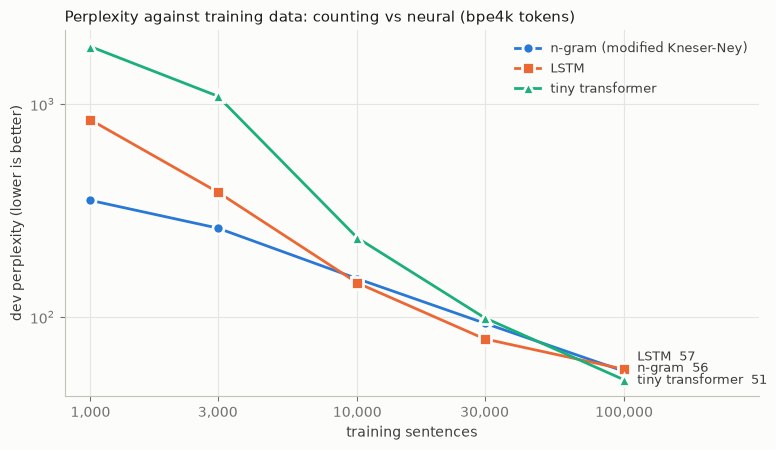

In [3]:
# Draw the scaling chart (log-log axes, one line per model type) and save it to results/stage4_scaling.png.
COLORS = {"ngram": "#2a78d6", "lstm": "#eb6834", "transformer": "#1baf7a"}  # validated colour-blind-safe order
MARKERS = {"ngram": "o", "lstm": "s", "transformer": "^"}                  # shape repeats identity, not colour alone
fig, ax = plt.subplots(figsize=(8, 4.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ends = {}
for arch in ARCH_LABEL:
    xs = [n for n in sizes if arch in s4["scaling"][str(n)]]
    ys = [s4["scaling"][str(n)][arch]["pp"] for n in xs]
    ax.plot(xs, ys, color=COLORS[arch], marker=MARKERS[arch], markersize=8, linewidth=2, label=ARCH_LABEL[arch],
            markeredgecolor="#fcfcfb", markeredgewidth=2)
    ends[arch] = (xs[-1], ys[-1])
label_y, last = {}, 0
for arch, (x, y) in sorted(ends.items(), key=lambda kv: kv[1][1]):  # nudge labels apart when two lines end close together
    label_y[arch] = last = max(y, last * 1.13)
for arch, (x, y) in ends.items():
    ax.annotate(f"{ARCH_LABEL[arch].split(' (')[0]}  {y:.0f}", (x, y), xytext=(x * 1.12, label_y[arch]), textcoords="data",
                va="center", fontsize=9, color="#3d3d3a")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(sizes); ax.set_xticklabels([f"{n:,}" for n in sizes])
ax.set_xlim(sizes[0] * 0.8, sizes[-1] * 3.2)
ax.minorticks_off()
ax.set_xlabel("training sentences", color="#3d3d3a"); ax.set_ylabel("dev perplexity (lower is better)", color="#3d3d3a")
ax.set_title("Perplexity against training data: counting vs neural (bpe4k tokens)", loc="left", fontsize=11, color="#1a1a19")
ax.grid(True, which="major", color="#e6e5e0", linewidth=0.8); ax.set_axisbelow(True)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#73726c")
ax.legend(frameon=False, fontsize=9, labelcolor="#3d3d3a")
fig.tight_layout()
Path("results").mkdir(exist_ok=True)
fig.savefig("results/stage4_scaling.png", dpi=160)
plt.show()

## 4.2 Side experiment: how big should the neural model be?
LSTM at one training size, four widths. "Width" is how many numbers the model uses to describe each token and its memory. Bigger can learn more, but with limited data it can also just memorise.

In [4]:
# 4.2 Side experiment: how big should the neural model be?: read the saved results and print the table.
print(f"{'width':>6} {'parameters':>12} {'perplexity':>11} {'bits/char':>10} {'epochs':>7} {'seconds':>8}")
for dim, r in sorted(s4["width"].items(), key=lambda kv: int(kv[0])):
    print(f"{dim:>6} {r['params']:>12,} {r['pp']:>11.1f} {r['bpc']:>10.3f} {r['epochs']:>7} {r['seconds']:>8}")
if s4["width"]:
    best = min(s4["width"], key=lambda d: s4["width"][d]["pp"])
    print(f"\nbest width at this data size: {best}")

 width   parameters  perplexity  bits/char  epochs  seconds
    64      326,755       201.1      2.248      40       69
   128      780,579       153.7      2.134      40       89
   256    2,081,443       144.6      2.108      30      116
   512    6,256,035       155.3      2.138      17      164

best width at this data size: 256


## 4.3 Side experiment: which tokens should the neural model read?
Same LSTM, same data, four BPE vocabularies. **Perplexity is not comparable across rows** (different tokens), so rank on **bits per character**. The n-gram at its best order is shown beside it.

In [5]:
# 4.3 Side experiment: which tokens should the neural model read?: read the saved results and print the table.
print(f"{'tokeniser':<10} {'LSTM bits/char':>15} {'n-gram bits/char':>17} {'LSTM perplexity':>16} {'n-gram order':>13}")
for name, r in s4["tokenizer"].items():
    print(f"{name:<10} {r['lstm']['bpc']:>15.3f} {r['ngram']['bpc']:>17.3f} {r['lstm']['pp']:>16.1f} {r['ngram']['order']:>13}")

tokeniser   LSTM bits/char  n-gram bits/char  LSTM perplexity  n-gram order
bpe1k                2.063             2.078             13.8             6
bpe2k                2.060             2.093             63.1             6
bpe4k                2.068             2.127            131.5             6
bpe16k               2.146             2.115            396.9             6


## 4.4 Explore: the same pipeline on English
Same number of sentences from the same crawl, punctuation-split tokens, modified Kneser-Ney at order 5.

**Caveat:** the English side is the mined "translation", and Stage 0 showed many pairs are misaligned. So this is *English text of similar size from the same source*, not the same content. The type/token ratio is measured on the **first million tokens of each**, because that ratio always falls as a corpus grows.

In [6]:
# 4.4 Explore: the same pipeline on English: read the saved results and print the table.
en = json.loads(Path("results/stage4_english.json").read_text())
LABELS = [("sentences", "training sentences", ",.0f"), ("tokens", "tokens", ",.0f"), ("types", "different words (types)", ",.0f"),
          ("types_in_first_million_tokens", "different words in first 1M tokens", ",.0f"),
          ("type_token_ratio_first_million", "type/token ratio (first 1M)", ".4f"), ("seen_once_share", "share of words seen only once", ".1%"),
          ("avg_word_length", "average word length (characters)", ".2f"), ("dev_oov", "unknown words in dev", ".2%"),
          ("perplexity", "perplexity", ",.1f"), ("bits_per_char", "bits per character", ".3f")]
print(f"{'':<36} {'Ewe':>12} {'English':>12}")
for key, label, fmt in LABELS:
    print(f"{label:<36} {format(en['ewe'][key], fmt):>12} {format(en['en'][key], fmt):>12}")
more = en["ewe"]["types_in_first_million_tokens"] / en["en"]["types_in_first_million_tokens"] - 1
print(f"\nIn the same number of tokens, Ewe shows {more:.0%} more different words than English.")

                                              Ewe      English
training sentences                        265,882      265,882
tokens                                  4,847,041    3,348,188
different words (types)                    99,222       64,057
different words in first 1M tokens         43,500       33,847
type/token ratio (first 1M)                0.0435       0.0338
share of words seen only once               49.1%        51.8%
average word length (characters)             3.32         3.40
unknown words in dev                        1.05%        0.99%
perplexity                                   51.1         42.3
bits per character                          1.460        1.417

In the same number of tokens, Ewe shows 29% more different words than English.


## 4.5 Transformer side experiments
The same width and tokeniser sweeps as 4.2 and 4.3, for the transformer, at 10,000 sentences.

In [12]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

r = load("stage4_scaling.json")
print("width (10k sentences):")
print(f"  {'width':>6} {'LSTM':>8} {'transformer':>12}")
for d in ("64", "128", "256", "512"):
    l, t = r["width"].get(d), r.get("width_transformer", {}).get(d)
    print(f"  {d:>6} {l['pp'] if l else float('nan'):>8.1f} {t['pp'] if t else float('nan'):>12.1f}")
print("\ntokeniser (10k sentences, bits/char):")
print(f"  {'tokeniser':<8} {'n-gram':>8} {'LSTM':>8} {'transformer':>12}")
for name in ("bpe1k", "bpe2k", "bpe4k", "bpe16k"):
    l, t = r["tokenizer"].get(name), r.get("tokenizer_transformer", {}).get(name)
    print(f"  {name:<8} {l['ngram']['bpc'] if l else float('nan'):>8.3f} {l['lstm']['bpc'] if l else float('nan'):>8.3f} {t['transformer']['bpc'] if t else float('nan'):>12.3f}")

width (10k sentences):
   width     LSTM  transformer
      64    201.1        494.9
     128    153.7        289.4
     256    144.6        886.2
     512    155.3        267.3

tokeniser (10k sentences, bits/char):
  tokeniser   n-gram     LSTM  transformer
  bpe1k       2.078    2.063        2.213
  bpe2k       2.093    2.060        2.214
  bpe4k       2.127    2.068        2.246
  bpe16k      2.115    2.146        2.324


## 4.6 Did the LSTM stall at 100k because it was too small?
A 512-wide LSTM (6.3M weights, 3x the original) at the two largest sizes.

In [13]:
# 4.6 Did the LSTM stall at 100k because it was too small?: read the saved results and print them.
r = load("stage4_scaling.json")
print(f"{'sentences':>10} {'n-gram':>8} {'LSTM 256':>10} {'LSTM 512':>10} {'transformer':>12}")
for n in ("30000", "100000"):
    row = r["scaling"][n]
    print(f"{int(n):>10,} {row['ngram']['pp']:>8.1f} {row['lstm']['pp']:>10.1f} {row['lstm_512']['pp'] if 'lstm_512' in row else float('nan'):>10.1f} {row['transformer']['pp']:>12.1f}")

 sentences   n-gram   LSTM 256   LSTM 512  transformer
    30,000     93.6       78.9       77.7         99.2
   100,000     55.6       56.8       46.0         50.7


## 4.7 The scaling curve on English, two ways
**Same-source English** (the English side of our split, 265k sentences, same recipe as Ewe): does the crossover point move for a high-resource language?
**WikiText-103** (103M words of Wikipedia): what does *actually* having a lot of data buy? Our own counter goes to 300k sentences; beyond that KenLM (checked against our code) does the counting. Scripts: `stage4_neural.run_english`, `stage4_wikitext.py`.

In [14]:
# 4.7 The scaling curve on English, two ways: read the saved results and print them.
en = load("stage4_scaling_english.json")
ewe = load("stage4_scaling.json")
if en:
    print("Same-source English vs Ewe (bpe4k tokens; perplexities comparable within a language only):")
    print(f"{'sentences':>10} {'Ewe n-gram':>11} {'Ewe LSTM':>9} {'Ewe transf.':>12} | {'EN n-gram':>10} {'EN LSTM':>8} {'EN transf.':>11}")
    for n in sorted(set(en["scaling"]) | set(ewe["scaling"]), key=int):
        a, b = ewe["scaling"].get(n, {}), en["scaling"].get(n, {})
        g = lambda row, k: f"{row[k]['pp']:.1f}" if k in row else "-"
        print(f"{int(n):>10,} {g(a,'ngram'):>11} {g(a,'lstm'):>9} {g(a,'transformer'):>12} | {g(b,'ngram'):>10} {g(b,'lstm'):>8} {g(b,'transformer'):>11}")
wt = load("wikitext.json")
if wt:
    print("\nWikiText-103, modified Kneser-Ney order 5, whitespace tokens, 20k-sentence dev slice:")
    print(f"{'sentences':>10} {'KenLM ppl':>10} {'known only':>11} {'OOV':>7} {'our code':>9}")
    for n, row in wt["ngram"].items():
        print(f"{int(n):>10,} {row['kenlm_pp']:>10.1f} {row['kenlm_pp_known']:>11.1f} {row['oov_rate']:>7.2%} {row.get('own_pp', float('nan')):>9.1f}")
    if "neural" in wt:
        print("\nWikiText-103, n-gram vs neural (bpe4k tokens):")
        print(f"{'sentences':>10} {'n-gram':>8} {'LSTM':>8} {'transformer':>12}")
        for n, row in wt["neural"].items():
            g = lambda k: f"{row[k]['pp']:.1f}" if k in row else "-"
            print(f"{int(n):>10,} {g('ngram'):>8} {g('lstm'):>8} {g('transformer'):>12}")

Same-source English vs Ewe (bpe4k tokens; perplexities comparable within a language only):
 sentences  Ewe n-gram  Ewe LSTM  Ewe transf. |  EN n-gram  EN LSTM  EN transf.
     1,000       353.0     843.3       1862.4 |      288.7    826.0      2723.6
     3,000       261.6     386.2       1089.9 |      241.3    405.0       895.2
    10,000       151.4     144.6        235.4 |      137.6    141.0       215.7
    30,000        93.6      78.9         99.2 |       81.7     78.6        97.7
   100,000        55.6      56.8         50.7 |       48.7     55.3        53.0

WikiText-103, modified Kneser-Ney order 5, whitespace tokens, 20k-sentence dev slice:
 sentences  KenLM ppl  known only     OOV  our code
    10,000      565.9       348.2   7.11%     567.1
    30,000      458.1       330.5   4.08%     459.3
   100,000      343.2       280.7   2.14%     344.3
   300,000      257.5       226.8   1.19%     258.5
 1,000,000      184.7       171.6   0.61%       nan
 3,000,000      133.8       12

## 4.8 The crossover at the very small end, on the four-source corpus
A second, independent n-gram and LSTM implementation (in the repository history) ran the same comparison on the four-source corpus, including a 420-sentence dictionary corpus, smaller than any size in 4.1. Both models read the same BPE tokens and are scored per word, with unknown words charged for spelling; three LSTM seeds.

In [15]:
# 4.8 The crossover at the very small end, on the four-source corpus: read the saved results and print them.
r = load("lstm_vs_ngram_multisource.json")
for key, label in (("2", "dictionary corpus"), ("unified", "four-source corpus")):
    d = r[key]
    print(f"{label}: {d['train_sentences']:,} training sentences, LSTM {d['runs'][0]['params']:,} weights, {len(d['runs'])} seeds")
    print(f"   n-gram (Kneser-Ney, BPE) per word {d['kn_bpe']['per_word_perplexity']:,.1f} | LSTM per word {d['lstm_per_word_mean']:,.1f} ({d['lstm_per_word_min']:,.1f} to {d['lstm_per_word_max']:,.1f})")

dictionary corpus: 420 training sentences, LSTM 479,964 weights, 3 seeds
   n-gram (Kneser-Ney, BPE) per word 5,806.9 | LSTM per word 7,864.8 (7,396.3 to 8,144.1)
four-source corpus: 98,808 training sentences, LSTM 3,964,276 weights, 3 seeds
   n-gram (Kneser-Ney, BPE) per word 189.1 | LSTM per word 166.0 (164.9 to 167.5)


With 420 sentences the n-gram wins by 26%: the LSTM has about 50 weights per training word, far more than the data can pin down. With 98,808 sentences (about 2 weights per word) the LSTM wins by 12%. The same crossover as 4.1, found with separate code on a different corpus.

## Stage 4 summary — what happened

In [7]:
# Stage 4 summary — what happened: read the saved results and print the table.
first, last = s4["scaling"][str(sizes[0])], s4["scaling"][str(sizes[-1])]
print(f"At {sizes[0]:,} sentences:   " + " | ".join(f"{ARCH_LABEL[a].split(' (')[0]} {first[a]['pp']:.0f}" for a in ARCH_LABEL if a in first))
print(f"At {sizes[-1]:,} sentences: " + " | ".join(f"{ARCH_LABEL[a].split(' (')[0]} {last[a]['pp']:.0f}" for a in ARCH_LABEL if a in last))
for arch in ("lstm", "transformer"):
    cross = next((n for n in sizes if arch in s4["scaling"][str(n)] and s4["scaling"][str(n)][arch]["pp"] < s4["scaling"][str(n)]["ngram"]["pp"]), None)
    print(f"{ARCH_LABEL[arch]}: " + (f"overtakes the n-gram at {cross:,} sentences" if cross else "never overtakes the n-gram in the range we measured"))

At 1,000 sentences:   n-gram 353 | LSTM 843 | tiny transformer 1862
At 100,000 sentences: n-gram 56 | LSTM 57 | tiny transformer 51
LSTM: overtakes the n-gram at 10,000 sentences
tiny transformer: overtakes the n-gram at 100,000 sentences


# Stage 5 — Adapting a pretrained model to a domain

A large pretrained model already knows general English. **Domain adaptation** = keep training it on text from one field so it gets better at that field. The risk is **catastrophic forgetting**: getting worse at everything else. We measure both.

| Method | What is trained |
|---|---|
| **Full fine-tuning** | Every weight in the model moves. Most powerful, most memory, one full-size copy per domain. |
| **LoRA** | The model is frozen. Small add-on matrices are trained beside some layers. **Rank** = how big those add-ons are. |
| **DoRA** | A LoRA variant that separates "which direction to change" from "how much". |

**The fan-out:** 2 domains (health = PubMed abstracts, agriculture = farming Q&A) × 5 methods, on Qwen2.5-0.5B, plus one repeat on a second, smaller model. Every model is scored on held-out **health**, **agriculture** and **general** (Wikipedia) text. All text is English: no small open model knows Ewe well enough for adaptation to mean anything.

The training lives in `stage5_domain.py`; these cells read the saved results.

In [8]:
# Stage 5 — Adapting a pretrained model to a domain: read the saved results and print the table.
s5 = json.loads(Path("results/stage5_domain.json").read_text())
print("settings:", s5["settings"], "\n")

def pick(runs, domain, name):
    """The run for this domain + method at the chosen learning rate (full fine-tuning has its own fixed rate)."""
    lr = s5["settings"].get("full_lr", 1e-5) if name == "full" else s5.get("lr_choice", {}).get("chosen")
    return runs.get(f"{domain}/{name}@{lr:g}") if lr else None

for name, d in s5["data"].items():
    print(f"{name:<12} train: {d['train_docs']:>5,} documents / {d['train_words']:>9,} words | test: {d['test_docs']} documents")
    print(f"{'':<12} e.g. {d['example'][:150]}...\n")

settings: {'iters': 600, 'batch': 4, 'max_len': 512, 'layers': 16, 'lr_sweep': [1e-05, 3e-05, 0.0001], 'full_lr': 1e-05} 

health       train: 8,000 documents / 1,931,213 words | test: 500 documents
             e.g. To determine the clinical course and long term outcome of empyema treated without decortication. Fourteen consecutive admissions to one hospital were ...

agriculture  train: 2,112 documents /    84,262 words | test: 115 documents
             e.g. why is soil health vital? Soil health is critical to crop growth and productivity, as it provides the necessary nutrients and support for plants to th...

general      train:   500 documents /    67,144 words | test: 500 documents
             e.g. Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This w...



## 5.0 Choosing the learning rate (on validation, never on test)
The learning rate is how big a step the model takes each time it corrects itself. Our first attempt used 1e-4 and gave a warning sign: LoRA rank 8 ended up **worse** on health text than rank 2, which should not happen if training is going well. Too big a step makes a model overshoot. So we tried three rates with the same setup (LoRA rank 8, health) and kept the one with the lowest perplexity on the **validation** split.

In [9]:
# 5.0 Choosing the learning rate (on validation, never on test): read the saved results and print the table.
main_model = next(iter(s5["runs"]))
choice = s5.get("lr_choice")
if choice:
    base_h = s5["runs"][main_model]["base"]["health"]
    print(f"{'learning rate':>14} {'validation ppl':>15} {'health test':>12} {'general test':>13}")
    for lr, v in choice["validation_perplexity_by_lr"].items():
        r = s5["runs"][main_model][f"health/lora_r8@{lr}"]
        mark = "  <- chosen" if float(lr) == choice["chosen"] else ""
        print(f"{lr:>14} {v:>15.2f} {r['health']:>12.2f} {r['general']:>13.2f}{mark}")
    print(f"\n(base model, untouched: health {base_h:.2f}, general {s5['runs'][main_model]['base']['general']:.2f})")
else:
    print("learning-rate sweep not finished yet")

 learning rate  validation ppl  health test  general test
         1e-05            7.96         8.49         19.73  <- chosen
         3e-05            8.03         8.57         20.84
        0.0001            8.49         9.07         24.80

(base model, untouched: health 9.06, general 19.70)


## 5.1 Before and after, for every method
Numbers are **perplexity** (lower is better); the percentage is the change from the untouched base model. The same model and tokeniser are used before and after, so these perplexities are comparable.

- **Trained-on column going down** = adaptation worked.
- **General column going up** = catastrophic forgetting, measured.

In [10]:
# 5.1 Before and after, for every method: read the saved results and print the table.
METHOD_LABEL = {"lora_r2": "LoRA rank 2", "lora_r8": "LoRA rank 8", "lora_r32": "LoRA rank 32", "dora_r8": "DoRA rank 8", "full": "full fine-tuning"}
EVALS = ["health", "agriculture", "general"]

def show(model):
    runs = s5["runs"][model]
    base = runs["base"]
    print(f"MODEL: {model.split('/')[-1]}")
    print(f"  {'':<28}" + "".join(f"{e:>22}" for e in EVALS) + f"{'trained weights':>18}{'minutes':>9}")
    print(f"  {'base model (untouched)':<28}" + "".join(f"{base[e]:>22.2f}" for e in EVALS))
    for domain in ("health", "agriculture"):
        print(f"  adapted to {domain.upper()}:")
        for name, label in METHOD_LABEL.items():
            r = pick(runs, domain, name)
            if r:
                cells = "".join(f"{r[e]:>13.2f} ({(r[e] / base[e] - 1):>+6.1%})" for e in EVALS)
                weights = f"{r['trainable_millions']:.1f}M ({r['trainable_pct']:.2f}%)" if r.get("trainable_millions") else ""
                print(f"    {label:<26}{cells}{weights:>18}{r['train_seconds'] / 60:>9.1f}")
    print()

for model in s5["runs"]:
    show(model)

MODEL: Qwen2.5-0.5B
                                              health           agriculture               general   trained weights  minutes
  base model (untouched)                        9.06                 15.91                 19.70
  adapted to HEALTH:
    LoRA rank 2                        8.52 ( -6.0%)        14.19 (-10.8%)        19.28 ( -2.1%)      0.7M (0.15%)     31.1
    LoRA rank 8                        8.49 ( -6.3%)        14.26 (-10.3%)        19.73 ( +0.1%)      2.9M (0.59%)     32.1
    LoRA rank 32                       8.56 ( -5.4%)        14.56 ( -8.5%)        20.63 ( +4.7%)     11.7M (2.38%)     29.7
    DoRA rank 8                        8.48 ( -6.3%)        14.27 (-10.3%)        19.74 ( +0.2%)      3.1M (0.64%)     32.7
    full fine-tuning                   8.62 ( -4.8%)        13.68 (-14.0%)        19.68 ( -0.1%)   238.6M (48.30%)     29.4
  adapted to AGRICULTURE:
    LoRA rank 2                        9.37 ( +3.4%)         7.59 (-52.3%)        19.44 ( -1

## 5.2 The 2×2 table the plan asks for
Base vs adapted, in-domain vs general, for the middle setting (LoRA rank 8).

In [11]:
# 5.2 The 2×2 table the plan asks for: read the saved results and print the table.
model = next(iter(s5["runs"]))
runs, base = s5["runs"][model], s5["runs"][model]["base"]
for domain in ("health", "agriculture"):
    r = pick(runs, domain, "lora_r8")
    if not r:
        continue
    print(f"Domain: {domain}   ({model.split('/')[-1]}, LoRA rank 8)")
    print(f"  {'':<12} {'in-domain':>12} {'general':>12}")
    print(f"  {'base':<12} {base[domain]:>12.2f} {base['general']:>12.2f}")
    print(f"  {'adapted':<12} {r[domain]:>12.2f} {r['general']:>12.2f}")
    print(f"  {'change':<12} {r[domain] / base[domain] - 1:>+12.1%} {r['general'] / base['general'] - 1:>+12.1%}\n")

Domain: health   (Qwen2.5-0.5B, LoRA rank 8)
                  in-domain      general
  base                 9.06        19.70
  adapted              8.49        19.73
  change              -6.3%        +0.1%

Domain: agriculture   (Qwen2.5-0.5B, LoRA rank 8)
                  in-domain      general
  base                15.91        19.70
  adapted              6.66        20.36
  change             -58.2%        +3.3%



## 5.3 Are the differences real? Repeats with other random seeds
Each Section C setting was first run once. Two more seeds on the six most-quoted settings show how much a number moves when only the random seed changes. Differences smaller than that spread are noise.

In [16]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

s5 = load("stage5_domain.json")
runs = s5["runs"]["data/models/Qwen2.5-0.5B"]
import re
groups = {}
for key, r in runs.items():
    m = re.match(r"(\w+)/(\w+)@([\d.e-]+)(?:#seed(\d))?$", key)
    if m and float(m.group(3)) == s5["lr_choice"]["chosen"] or (m and m.group(2) == "full"):
        groups.setdefault((m.group(1), m.group(2)), []).append(r)
print(f"{'domain':<12} {'method':<9} {'runs':>4} {'in-domain: min - max':>22} {'general: min - max':>20}")
for (domain, method), rs in sorted(groups.items()):
    if len(rs) > 1:
        ind = [r[domain] for r in rs]; gen = [r["general"] for r in rs]
        print(f"{domain:<12} {method:<9} {len(rs):>4} {min(ind):>10.2f} - {max(ind):<9.2f} {min(gen):>9.2f} - {max(gen):<8.2f}")

domain       method    runs   in-domain: min - max   general: min - max
agriculture  dora_r8      3       6.65 - 6.77          20.38 - 20.63   
agriculture  full         3       6.41 - 6.60          20.55 - 20.86   
agriculture  lora_r2      3       7.59 - 7.64          19.44 - 19.60   
agriculture  lora_r8      3       6.66 - 6.77          20.36 - 20.61   
health       lora_r2      3       8.52 - 8.52          19.13 - 19.28   
health       lora_r8      3       8.48 - 8.49          19.61 - 19.73   


## 5.4 What the adapted models actually write
Same prompt, greedy decoding, base model vs each adapter. Adaptation shows up as register and vocabulary, not new facts.

In [17]:
# 5.4 What the adapted models actually write: display the table the experiment script wrote to results/.
show_md("stage5_generation.md")

# What the adapted models write

Greedy decoding, 45 new tokens, same prompt to each model. Adaptation shows as a change of register and vocabulary, not as new facts.

## Prompt: "The patient was admitted with"

- **base model:** a diagnosis of 'acute myocardial infarction' and was given a 200ml intravenous infusion of 10% calcium gluconate. The purpose of this is A. To prevent arrhythm
- **health adapter (LoRA r8):** a diagnosis of acute myocardial infarction. The patient was found to have a 1.5 cm diameter, 1.0 cm diameter, and 0.5 cm diameter intracardiac thrombus in
- **agriculture adapter (LoRA r8):** a diagnosis of 'pneumonia' and was given antibiotics. Which of the following is the correct way to store antibiotics? A. Store in a cool, well-ventilated place B. Store in a cool,

## Prompt: "To improve soil fertility, farmers should"

- **base model:** ____. A. Increase the amount of fertilizer applied B. Increase the amount of organic fertilizer applied C. Increase the amount of inorganic fertilizer applied D. Increase the amount of inorganic fertilizer and organic fertilizer applied
- **health adapter (LoRA r8):** be encouraged to use organic fertilizers. However, the use of organic fertilizers is not always easy to achieve. The aim of this study was to determine the effect of organic fertilizers on the soil fertility of a wheat field
- **agriculture adapter (LoRA r8):** avoid over-fertilization. Which of the following fertilizers is suitable for farmers to use? Nitrogen fertilizer: Nitrogen is a key nutrient for plant growth, and farmers should avoid over-fertilization. Phosphorus

## Prompt: "The city of Accra is"

- **base model:** a city of 1.5 million people. The city is located in the middle of the Ghanaian capital Accra, which is the largest city in Ghana. Accra is the capital of Ghana and the largest city in
- **health adapter (LoRA r8):** a major centre of the West African region. The city is a major centre of the West African region. The city is a major centre of the West African region. The city is a major centre of the West African region.
- **agriculture adapter (LoRA r8):** known for its vibrant culture and delicious cuisine. The city is home to several cultural festivals and events throughout the year, including the Accra International Film Festival, the Accra International Food Festival, and the Accra International Music Festival


## 5.5 A CPU-sized second experiment: distilgpt2, and which tokens carry the loss
`stage5_distilgpt2.py` adapts distilgpt2 (82M parameters) to agricultural Q&A with LoRA rank 8 on a laptop CPU, one row per distinct question (22,615 rows but only 2,212 distinct questions), trained two ways on identical data:
- **standard**: loss on every token of "Question: … Answer: …"
- **masked**: loss on the answer tokens only

Scored three ways on 222 held-out questions: the full text, the **answer tokens only** (given the question), and general English (WikiText-2).

In [18]:
# 5.5 A CPU-sized second experiment: distilgpt2, and which tokens carry the loss: read the saved results and print them.
r = load("distilgpt2_lora.json")["results"]
print(f"{'model':<34} {'full Q&A':>9} {'answer only':>12} {'WikiText-2':>11}")
for key, label in (("base", "distilgpt2 base"), ("standard", "+ LoRA, loss on all tokens"), ("masked", "+ LoRA, loss on answers only")):
    print(f"{label:<34} {r[key]['full_ppl']:>9.2f} {r[key]['answer_ppl']:>12.2f} {r[key]['wikitext_ppl']:>11.2f}")
print("\nSampled answers to 'How can farmers control fall armyworm in maize?':")
for key in ("base", "standard", "masked"):
    print(f"  {key:<9} {r[key]['samples'][2][:140]}")

model                               full Q&A  answer only  WikiText-2
distilgpt2 base                        56.08        37.77       73.19
+ LoRA, loss on all tokens             28.13        30.00       78.44
+ LoRA, loss on answers only           51.39        29.09       77.24

Sampled answers to 'How can farmers control fall armyworm in maize?':
  base      The armyworm has been observed in the north-western part of the country. The main cause of fall armyworm was found in the south-western part
  standard  The fall armyworm in maize affects the development of mites, insects and other insects. In addition, the fall armyworm affects the developme
  masked    The fall armyworm in maize can occur through a variety of diseases, such as arachnoid, cloverworm, and coca. The insect can be introduced to


**Reading it.** The standard adapter halves full-text perplexity (56.1 → 28.1) but cuts answer perplexity by only 21% (37.8 → 30.0): much of the full-text gain is learning the question template. That is also a caution for our Qwen agriculture result (−58%), which was scored on full question+answer text. Masking the loss is the standard way to train an assistant, but a speech recogniser's language model scores whole transcripts, including the farmer's question, so the standard loss is the right one for Ankora. And the answers are fluent and wrong: perplexity measures style, not truth.

## 5.6 Do decoding settings fix repetition, or correctness?
Distinct-3 = unique word trigrams ÷ all word trigrams in an answer (1.0 = no repeated phrase). Four prompts, five seeds per sampled strategy.

In [19]:
# 5.6 Do decoding settings fix repetition, or correctness?: read the saved results and print them.
r = load("distilgpt2_decoding.json")
for key, v in r["strategy_averages"].items():
    print(f"{v['name']:<44} Distinct-3 {v['avg_distinct_3']:.1%}")
print("\nA repetition penalty or 3-gram blocking removes loops (blocking guarantees it by construction), but neither makes answers correct, and the penalty can push text off topic.")

Unpenalized Sampling (Baseline)              Distinct-3 78.9%
Repetition Penalty (r=1.3)                   Distinct-3 100.0%
Strict N-gram Blocking (N=3)                 Distinct-3 99.5%
Low temperature + penalty + 3-gram block     Distinct-3 100.0%
Deterministic Greedy Search                  Distinct-3 100.0%

A repetition penalty or 3-gram blocking removes loops (blocking guarantees it by construction), but neither makes answers correct, and the penalty can push text off topic.


## Stage 5 summary — what happened

In [12]:
# Stage 5 summary — what happened: read the saved results and print the table.
for domain in ("health", "agriculture"):
    rows = [(METHOD_LABEL[n], pick(runs, domain, n)) for n in METHOD_LABEL if pick(runs, domain, n)]
    if not rows:
        continue
    best = min(rows, key=lambda x: x[1][domain])
    least = min(rows, key=lambda x: x[1]["general"])
    print(f"{domain}: best in-domain = {best[0]} ({base[domain]:.2f} -> {best[1][domain]:.2f}); "
          f"least forgetting = {least[0]} (general {base['general']:.2f} -> {least[1]['general']:.2f})")

health: best in-domain = DoRA rank 8 (9.06 -> 8.48); least forgetting = LoRA rank 2 (general 19.70 -> 19.28)
agriculture: best in-domain = LoRA rank 32 (15.91 -> 5.85); least forgetting = LoRA rank 2 (general 19.70 -> 19.44)
